In [24]:
# importing required libraries
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
import missingno as mno
import warnings 
warnings.filterwarnings('ignore')
print('done')

done


In [25]:
# Evaluation parameters
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.dummy import DummyRegressor
# Model 1
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from tensorflow import keras
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import tensorflow as tf
from sklearn.ensemble import BaggingRegressor

# Loading data sets

In [26]:
df_training = pd.read_csv(#)

In [27]:
df_training

,DEPT,NEUT,DENS,DTC,RESM,GR,PEF,WELLNAME
0,659.5872,0.34758,2.2471,118.2797,11.4703,92.1177,3.1998,Ahuroa South B-1
1,659.7396,0.32441,2.2503,118.0861,11.6295,92.9298,3.1848,Ahuroa South B-1
2,659.8920,0.30124,2.2536,117.8926,11.7887,93.7420,3.1698,Ahuroa South B-1
3,660.0444,0.29313,2.2543,117.8988,11.8483,94.4243,3.1683,Ahuroa South B-1
4,660.1968,0.32163,2.2487,118.3909,11.6656,94.7903,3.1999,Ahuroa South B-1
...,...,...,...,...,...,...,...,...
506739,1308.3540,0.32734,2.4787,96.4259,4.8998,116.0878,3.2800,Wawiri-1
506740,1308.5064,0.32727,2.4799,96.5073,4.8998,116.5207,3.3053,Wawiri-1
506741,1308.6588,0.31979,2.4799,96.2745,4.9318,116.8138,3.3180,Wawiri-1
506742,1308.8112,0.31231,2.4798,96.0416,4.9637,117.1069,3.3306,Wawiri-1


In [28]:
df_training.describe()

,DEPT,NEUT,DENS,DTC,RESM,GR,PEF
count,506744.000000,506744.000000,506744.000000,506744.000000,506744.000000,506744.000000,506744.000000
mean,2427.138163,0.243249,2.455541,86.018879,3097.067865,88.475727,3.540840
std,1279.757814,0.097341,0.179496,18.811766,55433.645571,25.172431,1.152419
min,257.556000,0.000050,0.799980,4.169300,0.435400,0.019300,0.100000
25%,1320.393600,0.185160,2.370100,72.139550,3.780700,70.765325,3.048200
50%,2211.933600,0.252860,2.485500,82.518150,6.573650,91.035000,3.364300
75%,3532.936800,0.310930,2.579600,97.403825,13.138725,106.185450,3.781000
max,5634.990000,0.947500,2.991800,249.036900,1000000.000000,199.490000,73.103900


In [29]:
test_well1 = pd.read_csv(#)

In [30]:
test_well1.describe()

,DEPT,NEUT,DENS,DTC,RESM,GR,PEF
count,17662.000000,17662.000000,17662.000000,17662.000000,17662.000000,17662.000000,17662.000000
mean,2693.496977,0.251133,2.505404,84.621864,6.913616,80.800868,3.726584
std,777.389886,0.044312,0.098335,7.434489,8.497438,16.415708,0.317891
min,1347.520800,0.058040,1.298100,54.199700,1.398400,11.033600,1.713600
25%,2020.404900,0.226190,2.486625,81.709400,3.097325,69.979725,3.597100
50%,2693.289000,0.253255,2.522100,84.143850,5.015700,78.335250,3.748800
75%,3366.173100,0.276767,2.559200,86.858825,6.330575,89.991900,3.882100
max,4051.858800,0.714880,2.829500,146.610700,175.313100,159.687700,7.943000


In [31]:
test_well2 = pd.read_csv(#)

In [32]:
test_well2.describe()

,DEPT,NEUT,DENS,DTC,RESM,GR,PEF
count,9706.000000,9706.000000,9706.000000,9706.000000,9706.000000,9706.000000,9706.000000
mean,1526.770034,0.308364,2.398546,98.976379,8.459440,103.379970,3.273926
std,427.295724,0.032098,0.089134,10.581683,4.720314,12.508656,0.201229
min,786.536400,0.132770,2.198700,57.563800,2.370500,48.511600,2.598200
25%,1156.906500,0.285232,2.329125,87.972050,5.110875,95.267400,3.136600
50%,1526.971800,0.312390,2.385350,99.500850,6.463550,105.108300,3.302500
75%,1896.732300,0.332150,2.493400,107.620125,11.637550,112.688800,3.417700
max,2266.492800,0.405940,2.702900,129.858300,54.925600,166.205200,4.331000


<Axes: >

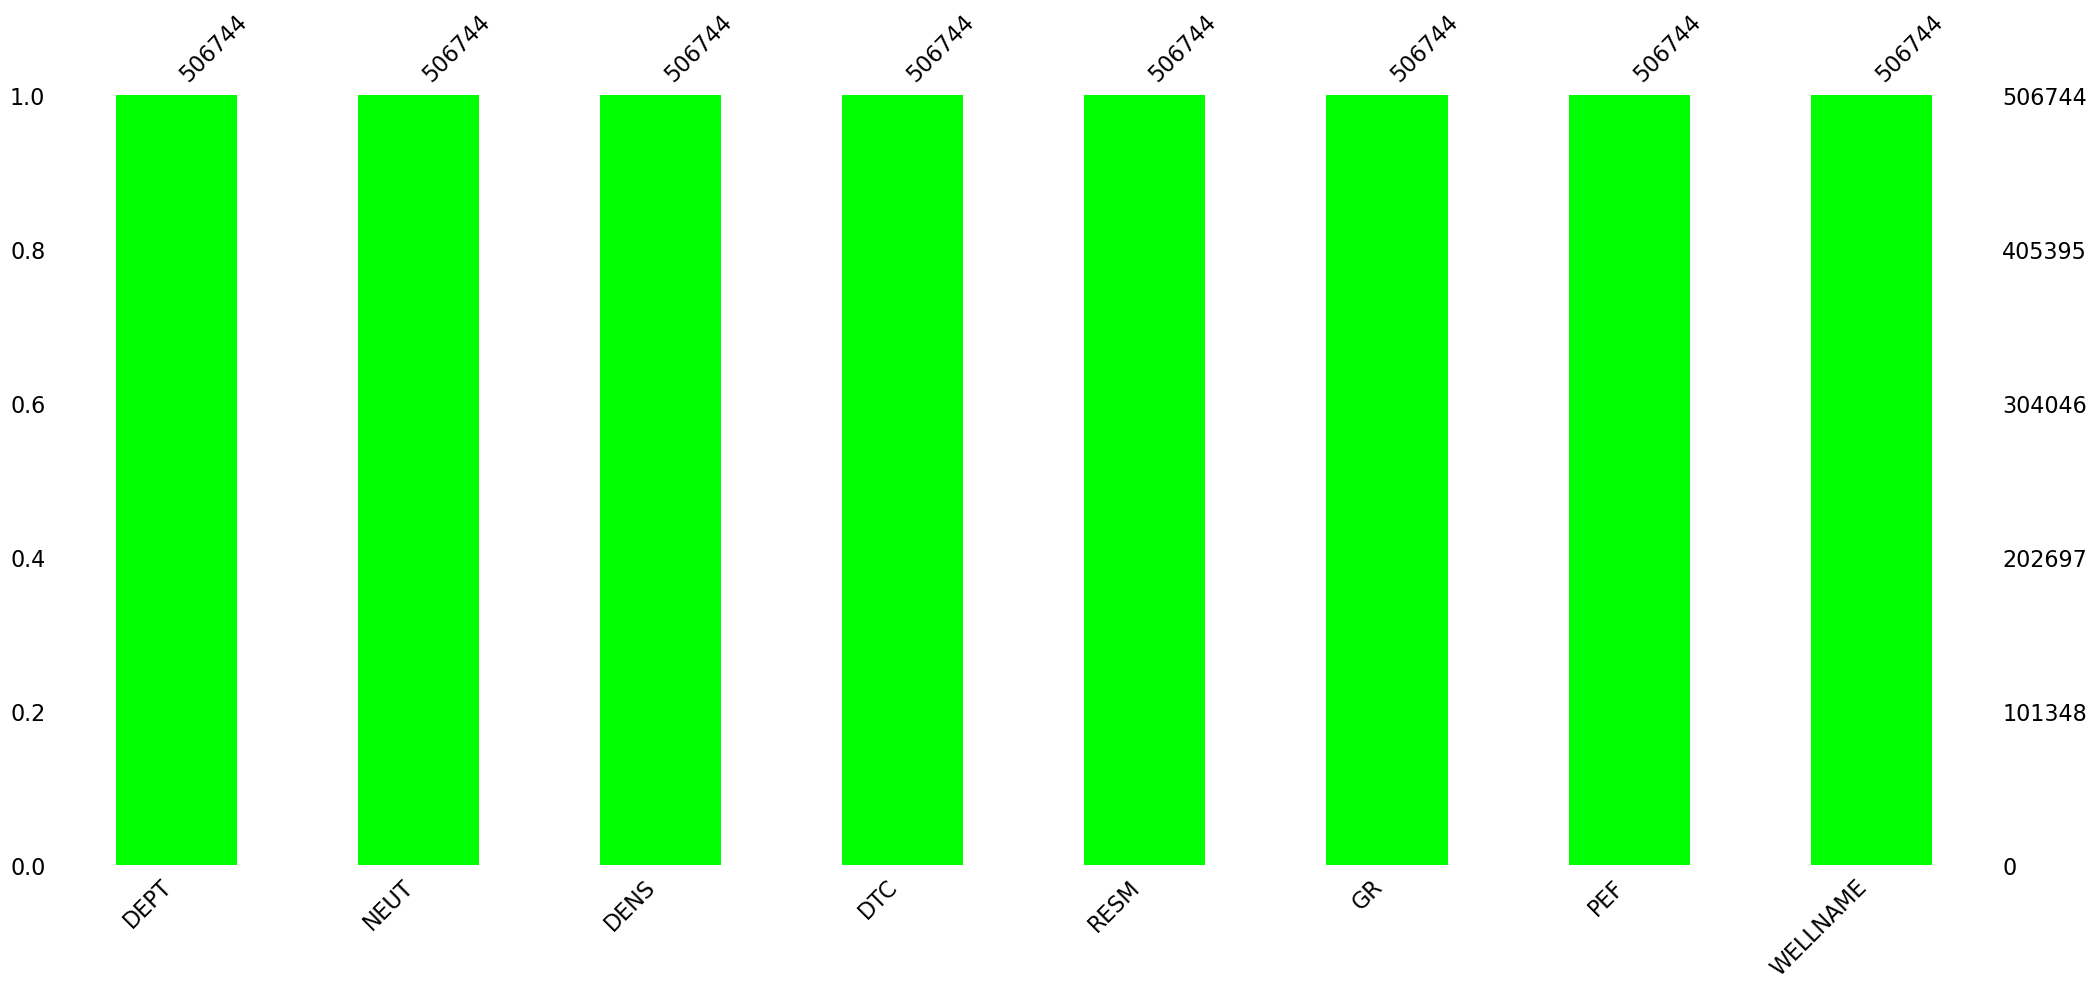

In [33]:
mno.bar(df_training, color = 'lime')

# Feature input

In [34]:
X = df_training[['DENS','DTC','RESM']]  
y = df_training['NEUT']

In [35]:
X

,DENS,DTC,RESM
0,2.2471,118.2797,11.4703
1,2.2503,118.0861,11.6295
2,2.2536,117.8926,11.7887
3,2.2543,117.8988,11.8483
4,2.2487,118.3909,11.6656
...,...,...,...
506739,2.4787,96.4259,4.8998
506740,2.4799,96.5073,4.8998
506741,2.4799,96.2745,4.9318
506742,2.4798,96.0416,4.9637


In [36]:
y

0         0.34758
1         0.32441
2         0.30124
3         0.29313
4         0.32163
           ...   
506739    0.32734
506740    0.32727
506741    0.31979
506742    0.31231
506743    0.30483
Name: NEUT, Length: 506744, dtype: float64

# Test unseen 1 (Kapuni-16)

In [37]:
X_tw1 = test_well1[['DENS','DTC','RESM']]
y_tw1 = test_well1['NEUT']

# Test unseen 2 (Cheal-B4)

In [38]:
X_tw2 = test_well2[['DENS','DTC','RESM']]
y_tw2 = test_well2['NEUT']

# Feature Scaling

In [39]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Transforming training data
X_trans = scaler.fit_transform(X)

# transforming test data
X_tw1_T = scaler.transform(X_tw1)
X_tw2_T = scaler.transform(X_tw2)

# Train test split

In [40]:
X_train, X_val, y_train, y_val = train_test_split(X_trans, y, test_size = 0.2)

# Model 0: DummyRegressor 
# Baseline model

In [41]:
from sklearn.dummy import DummyRegressor

In [42]:
model0 = DummyRegressor(strategy = 'median')
model0.fit(X_train, y_train)

DummyRegressor(strategy='median')

In [43]:
y_pred0 = model0.predict(X_val)

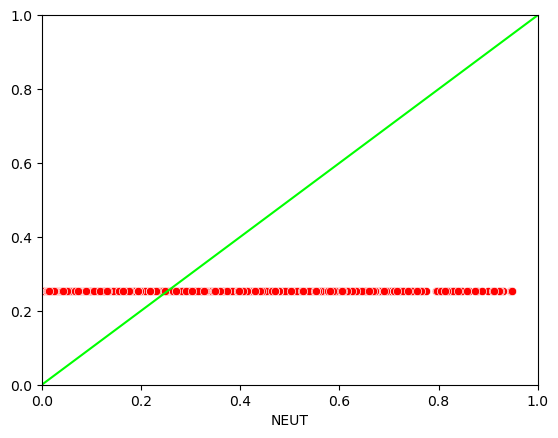

In [44]:
sns.scatterplot(x=y_val, y=y_pred0, color='red')
plt.xlim(0,1)
plt.ylim(0,1)
plt.plot((0, 1), (0, 1), color='lime')

In [45]:
mae0 = metrics.mean_absolute_error(y_val, y_pred0)
print("MAE_DR: ", mae0)

mse0 = metrics.mean_squared_error(y_val, y_pred0)
print('MSE_DR: ', mse0)

RMSE0 =mse0 ** 0.5
print('RMSE_DR: ', RMSE0)

r2_DR = metrics.r2_score(y_val,y_pred0) 
print("R2-Score DR: ",r2_DR)

MAE_DR:  0.07614742552960561
MSE_DR:  0.009526169265803313
RMSE_DR:  0.09760209662606287
R2-Score DR:  -0.009258614853671743


# Model 1 Multi Linear Regression

In [46]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

LinearRegression()

In [47]:
y_pred1 = model1.predict(X_val)

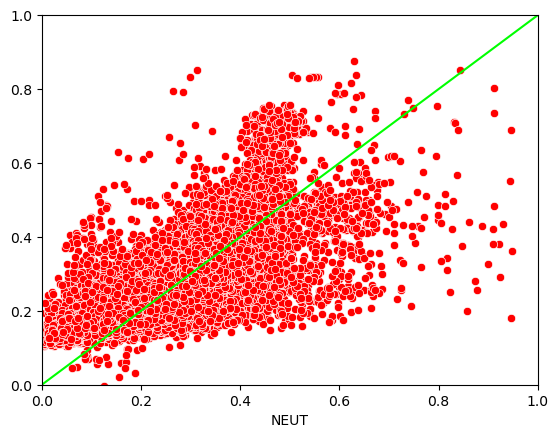

In [48]:
sns.scatterplot(x=y_val, y=y_pred1, color='red')
plt.xlim(0,1)
plt.ylim(0,1)
plt.plot((0, 1), (0, 1), color='lime')

In [49]:
y_pred1_tw1 = model1.predict(X_tw1_T)
y_pred1_tw2 = model1.predict(X_tw2_T)

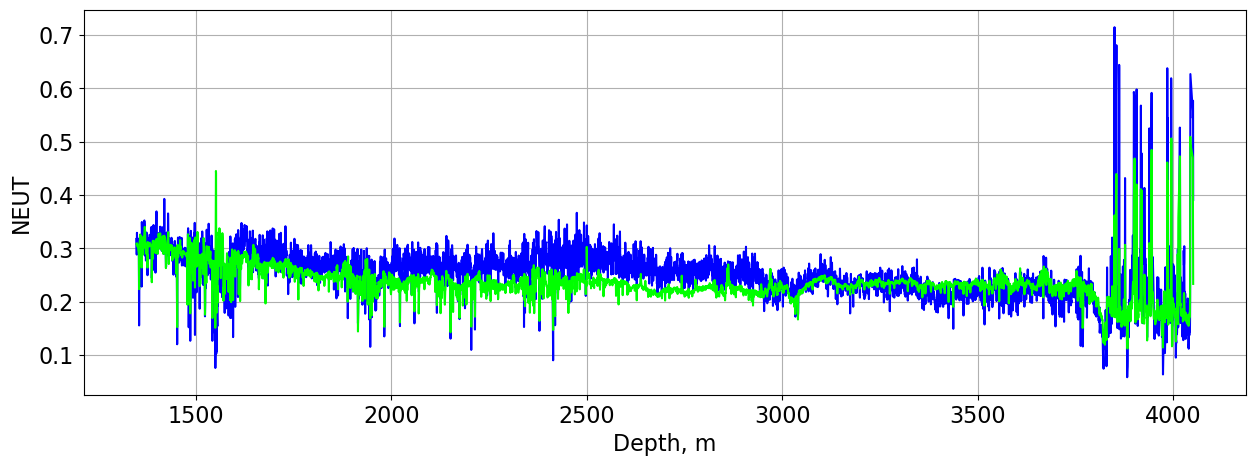

In [50]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color='blue')
plt.plot(test_well1['DEPT'], y_pred1_tw1, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

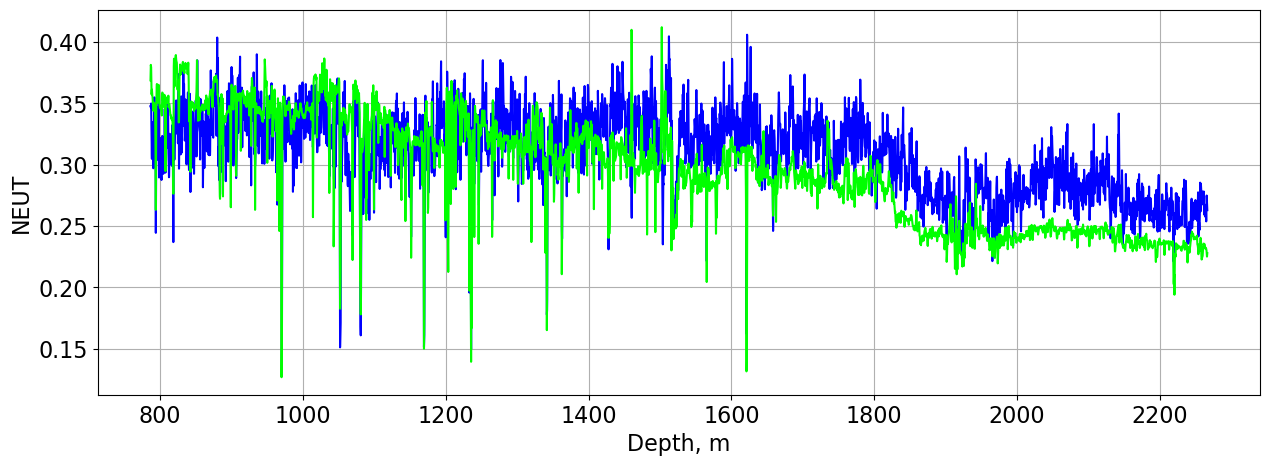

In [51]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color='blue')
plt.plot(test_well2['DEPT'], y_pred1_tw2, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

# Model 2: HistGradientBoostingRegressor
# Histogram-based Gradient Boosting Regression Tree.

In [52]:
model2 = HistGradientBoostingRegressor()
model2.fit(X_train, y_train)

HistGradientBoostingRegressor()

In [53]:
y_pred2 = model2.predict(X_val)

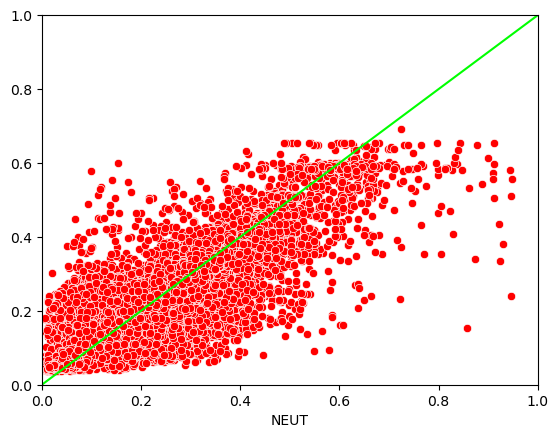

In [54]:
sns.scatterplot(x=y_val, y=y_pred2, color='red')
plt.xlim(0,1)
plt.ylim(0,1)
plt.plot((0, 1), (0, 1), color='lime')

In [55]:
y_pred2_tw1 = model2.predict(X_tw1_T)
y_pred2_tw2 = model2.predict(X_tw2_T)

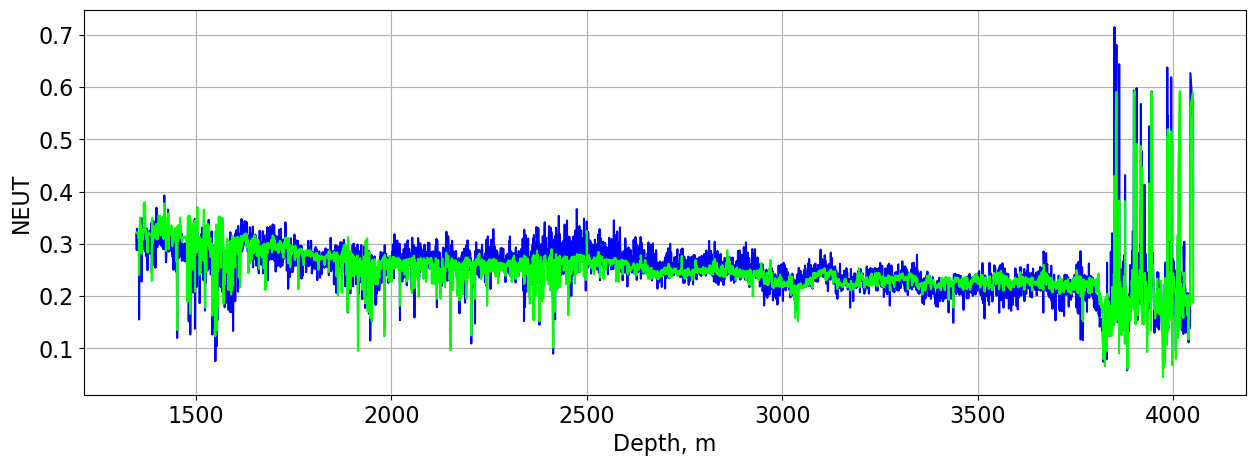

In [56]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color='blue')
plt.plot(test_well1['DEPT'], y_pred2_tw1, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

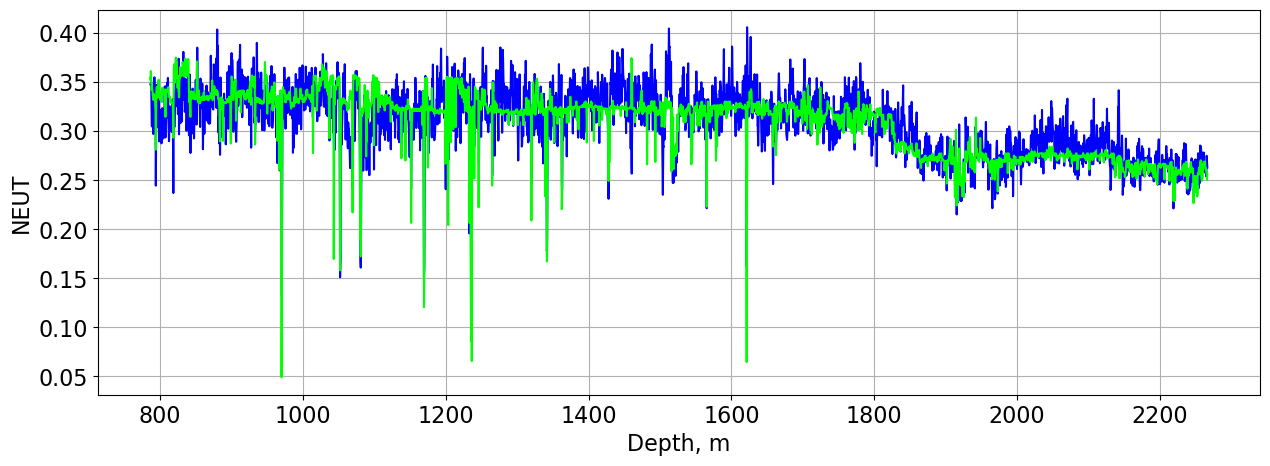

In [57]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color='blue')
plt.plot(test_well2['DEPT'], y_pred2_tw2, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

# Model 3: AdaBoostRegressor

In [58]:
model3 = AdaBoostRegressor()
model3.fit(X_train, y_train)

AdaBoostRegressor()

In [59]:
y_pred3 = model3.predict(X_val)

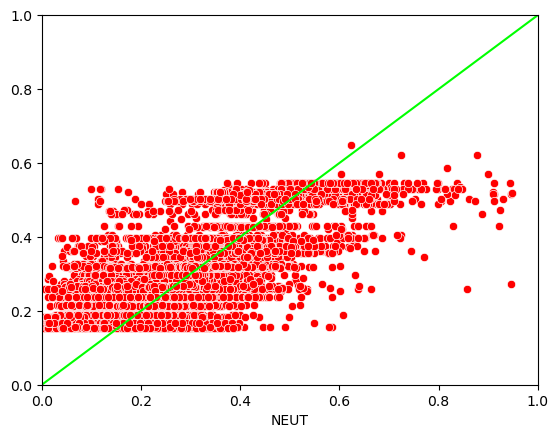

In [60]:
sns.scatterplot(x=y_val, y=y_pred3, color='red')
plt.xlim(0,1)
plt.ylim(0,1)
plt.plot((0, 1), (0, 1), color='lime')

In [61]:
y_pred3_tw1 = model3.predict(X_tw1_T)
y_pred3_tw2 = model3.predict(X_tw2_T)

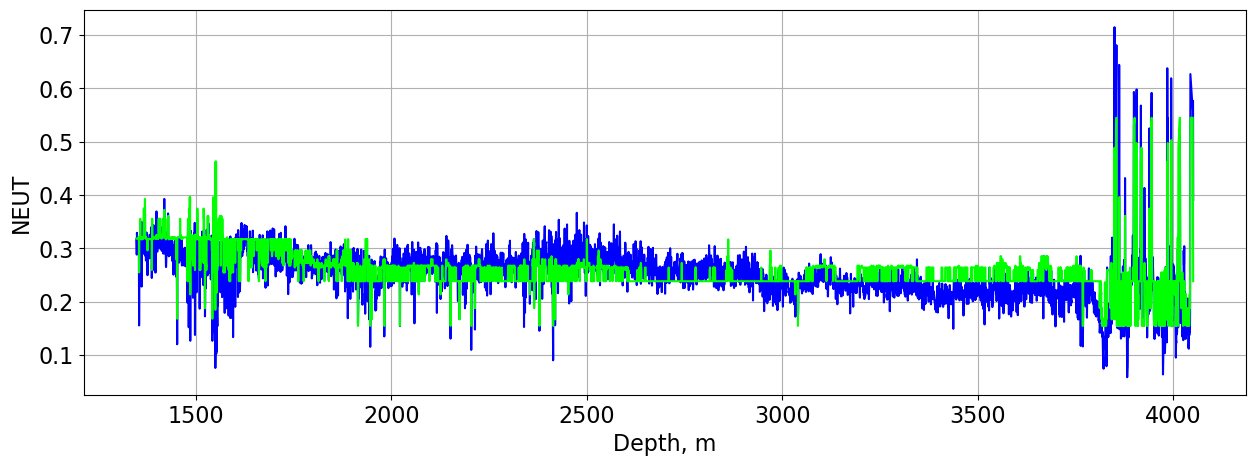

In [62]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color='blue')
plt.plot(test_well1['DEPT'], y_pred3_tw1, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

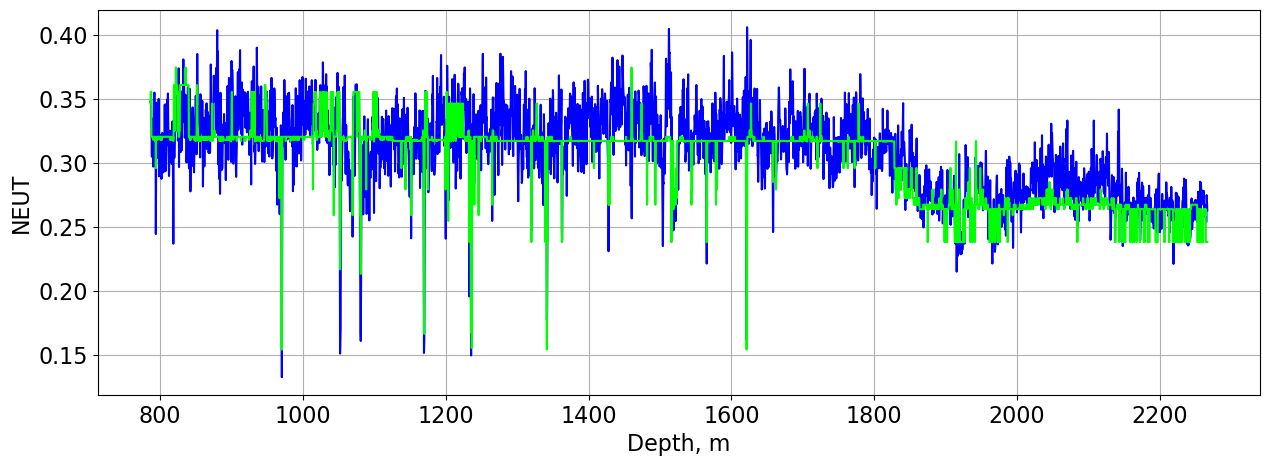

In [63]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color='blue')
plt.plot(test_well2['DEPT'], y_pred3_tw2, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

# Model 4: Decision Tree Regressor

In [64]:
model4 = DecisionTreeRegressor()
model4.fit(X_train, y_train)

DecisionTreeRegressor()

In [65]:
y_pred4 = model4.predict(X_val)

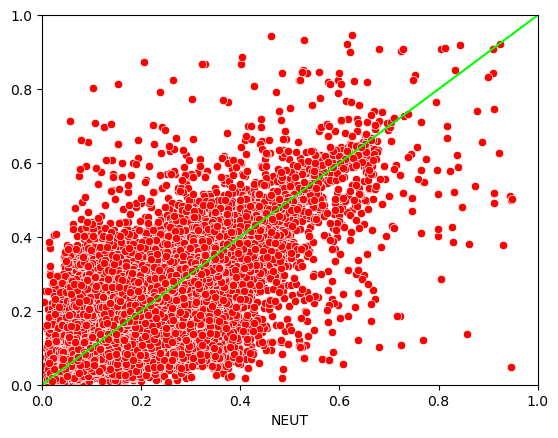

In [66]:
sns.scatterplot(x=y_val, y=y_pred4, color='red')
plt.xlim(0,1)
plt.ylim(0,1)
plt.plot((0, 1), (0, 1), color='lime')

In [67]:
y_pred4_tw1 = model4.predict(X_tw1_T)
y_pred4_tw2 = model4.predict(X_tw2_T)

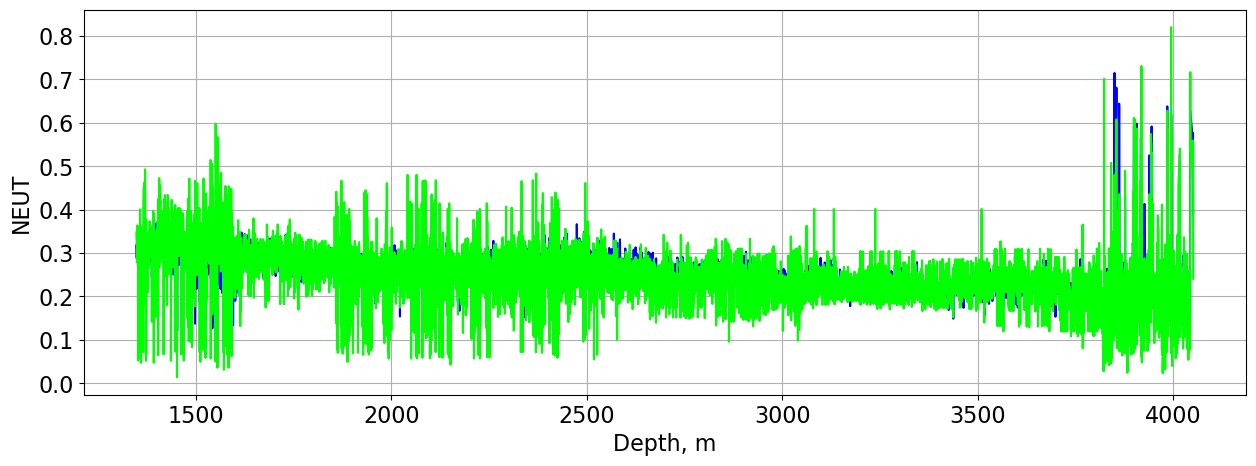

In [68]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color='blue')
plt.plot(test_well1['DEPT'], y_pred4_tw1, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

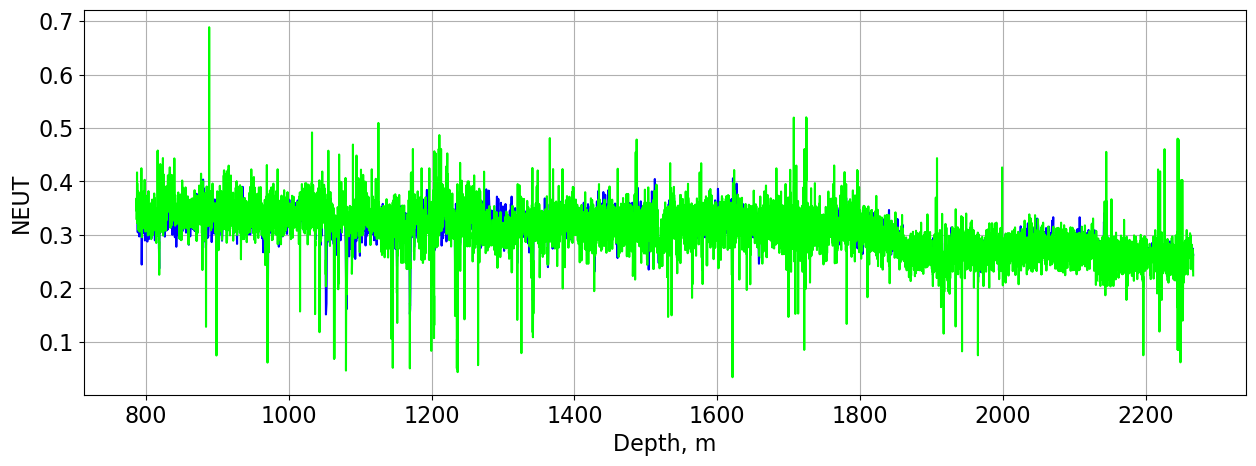

In [69]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color='blue')
plt.plot(test_well2['DEPT'], y_pred4_tw2, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

# Model 5: Random forest Regressor

In [70]:
model5 = RandomForestRegressor()
model5.fit(X_train, y_train)

RandomForestRegressor()

In [71]:
y_pred5 = model5.predict(X_val)

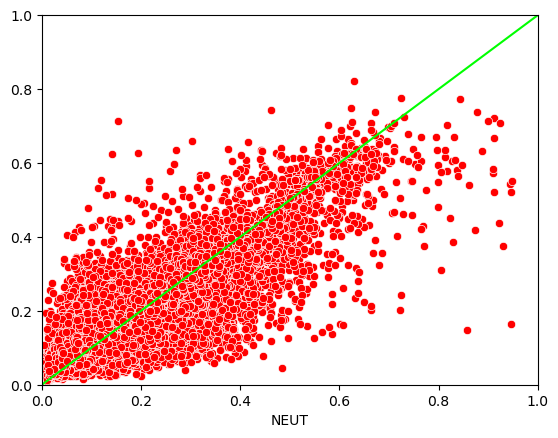

In [72]:
sns.scatterplot(x=y_val, y=y_pred5, color='red')
plt.xlim(0,1)
plt.ylim(0,1)
plt.plot((0, 1), (0, 1), color='lime')

In [73]:
y_pred5_tw1 = model5.predict(X_tw1_T)
y_pred5_tw2 = model5.predict(X_tw2_T)

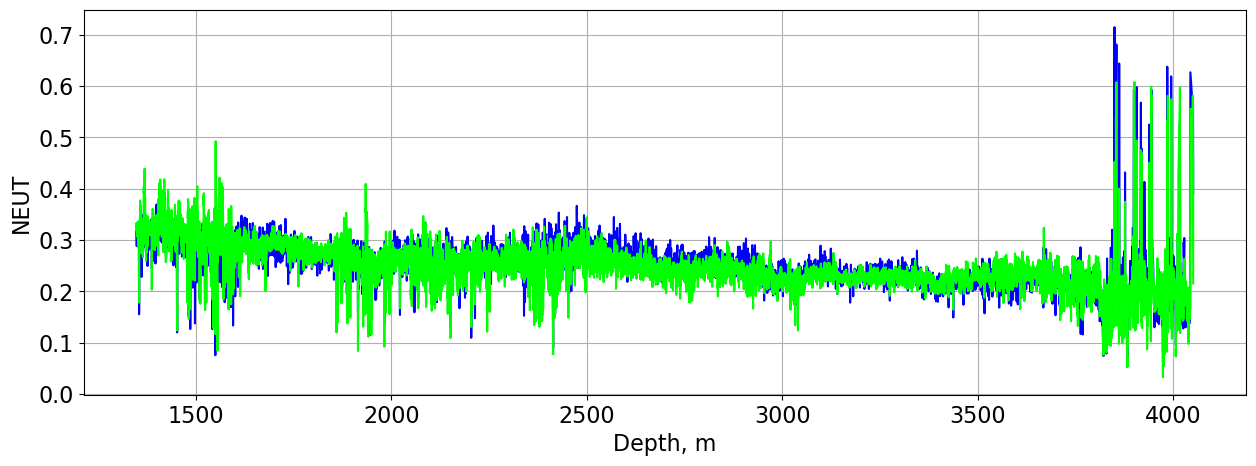

In [74]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color='blue')
plt.plot(test_well1['DEPT'], y_pred5_tw1, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

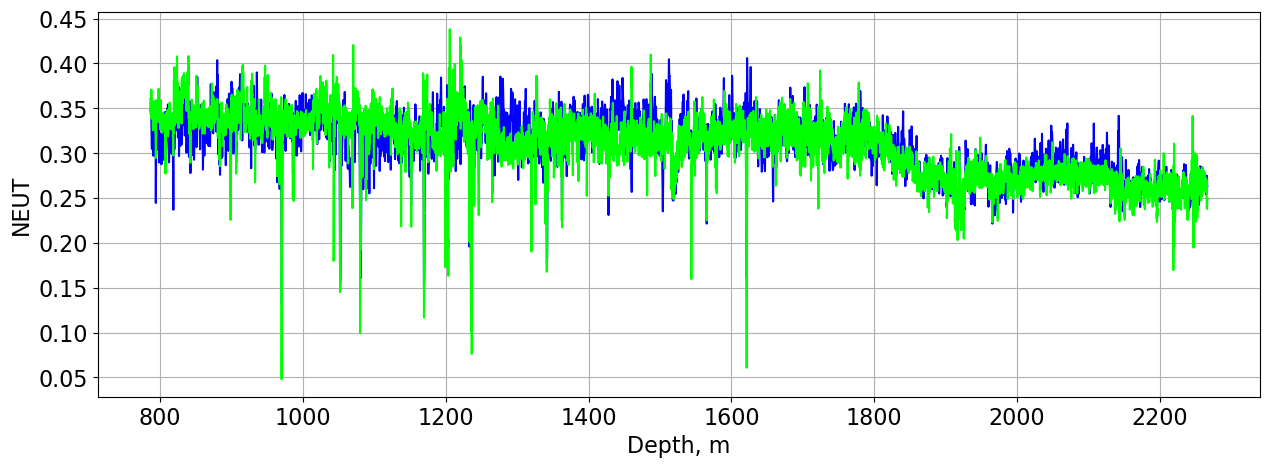

In [75]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color='blue')
plt.plot(test_well2['DEPT'], y_pred5_tw2, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

# Model 6: Gradient Boost Regressor

In [76]:
model6 = GradientBoostingRegressor()
model6.fit(X_train, y_train)

GradientBoostingRegressor()

In [77]:
y_pred6 = model6.predict(X_val)

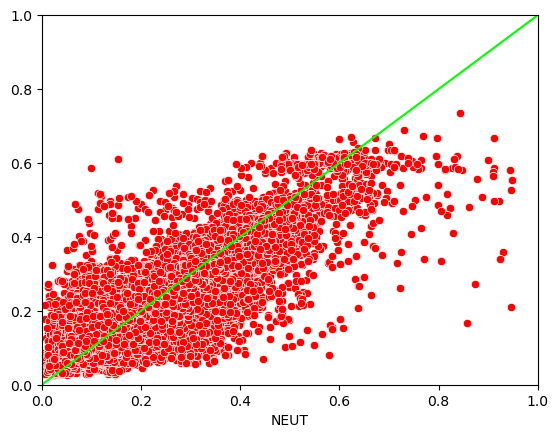

In [78]:
sns.scatterplot(x=y_val, y=y_pred6, color='red')
plt.xlim(0,1)
plt.ylim(0,1)
plt.plot((0, 1), (0, 1), color='lime')

In [79]:
y_pred6_tw1 = model6.predict(X_tw1_T)
y_pred6_tw2 = model6.predict(X_tw2_T)

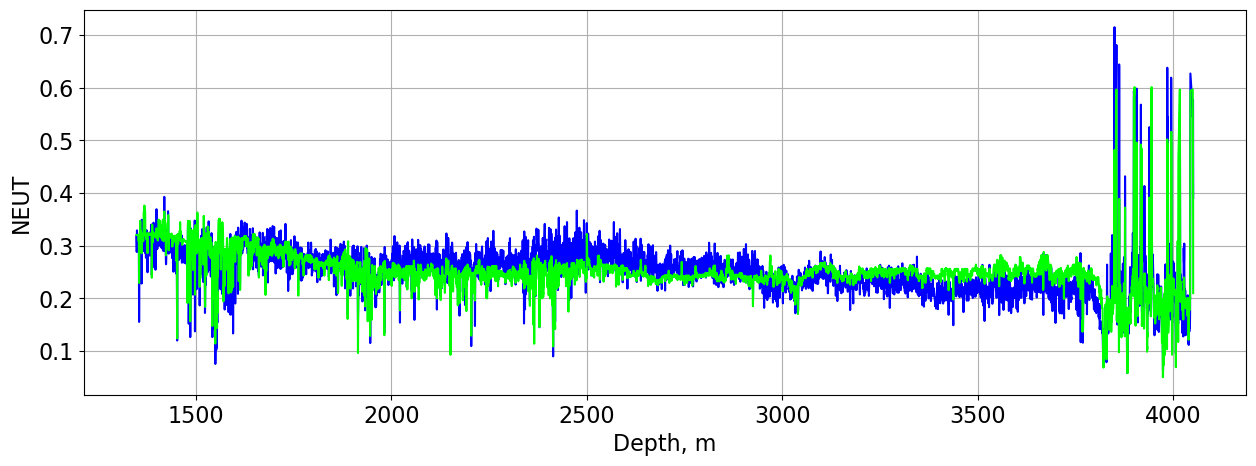

In [80]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color='blue')
plt.plot(test_well1['DEPT'], y_pred6_tw1, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

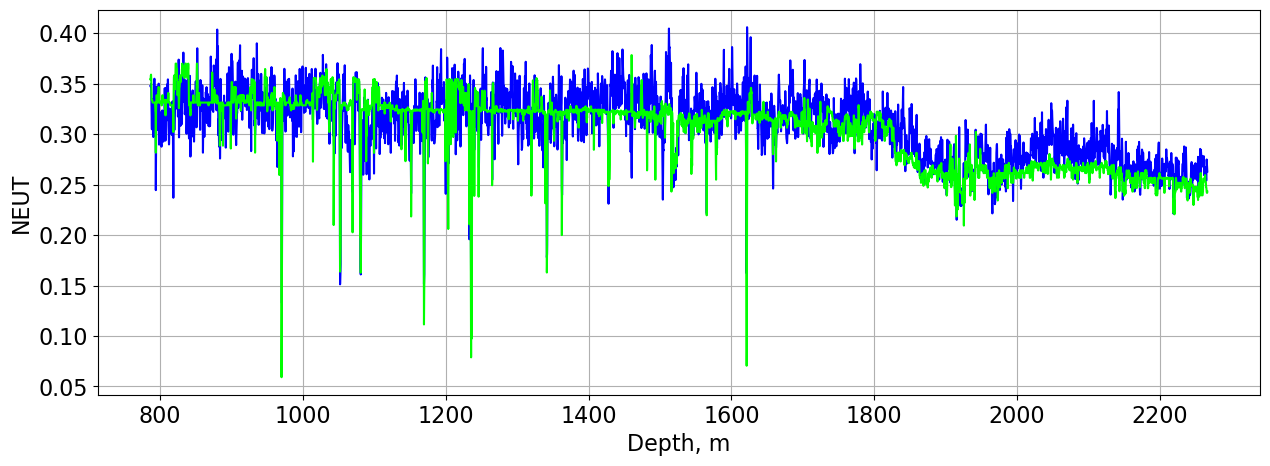

In [81]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color='blue')
plt.plot(test_well2['DEPT'], y_pred6_tw2, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

# Model 7: ANN

In [82]:
from tensorflow import keras

model7 = keras.Sequential([
    keras.layers.Dense(128, activation="relu", input_shape=(X_train.shape[1],)),  
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(1)
])

# Compile the model
model7.compile(loss="mse", optimizer="adam") 

model7.fit(X_train, y_train, epochs=50, batch_size=32)  

y_pred7 = model7.predict(X_val)



Epoch 1/50

12669/12669 [==============================] - 64s 4ms/step - loss: 0.0025
Epoch 2/50
12669/12669 [==============================] - 53s 4ms/step - loss: 0.0021
Epoch 3/50
12669/12669 [==============================] - 55s 4ms/step - loss: 0.0020
Epoch 4/50
12669/12669 [==============================] - 55s 4ms/step - loss: 0.0020
Epoch 5/50
12669/12669 [==============================] - 52s 4ms/step - loss: 0.0020
Epoch 6/50
12669/12669 [==============================] - 53s 4ms/step - loss: 0.0020
Epoch 7/50
12669/12669 [==============================] - 55s 4ms/step - loss: 0.0020
Epoch 8/50
12669/12669 [==============================] - 55s 4ms/step - loss: 0.0020
Epoch 9/50
12669/12669 [==============================] - 51s 4ms/step - loss: 0.0020
Epoch 10/50
12669/12669 [==============================] - 55s 4ms/step - loss: 0.0020
Epoch 11/50
12669/12669 [==============================] - 55s 4ms/step - loss: 0.0020
Epoch 12/50
12669/12669 [========================

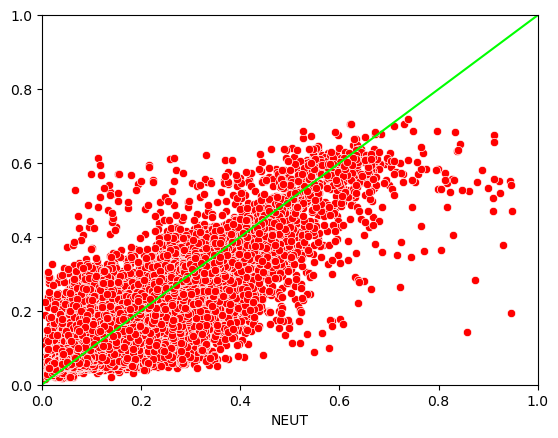

In [83]:
sns.scatterplot(x=y_val, y=y_pred7.reshape(1,-1)[0], color='red')
plt.xlim(0,1)
plt.ylim(0,1)
plt.plot((0, 1), (0, 1), color='lime')

In [84]:
y_pred7_tw1 = model7.predict(X_tw1_T)
y_pred7_tw2 = model7.predict(X_tw2_T)

304/304 [==============================] - 1s 3ms/step


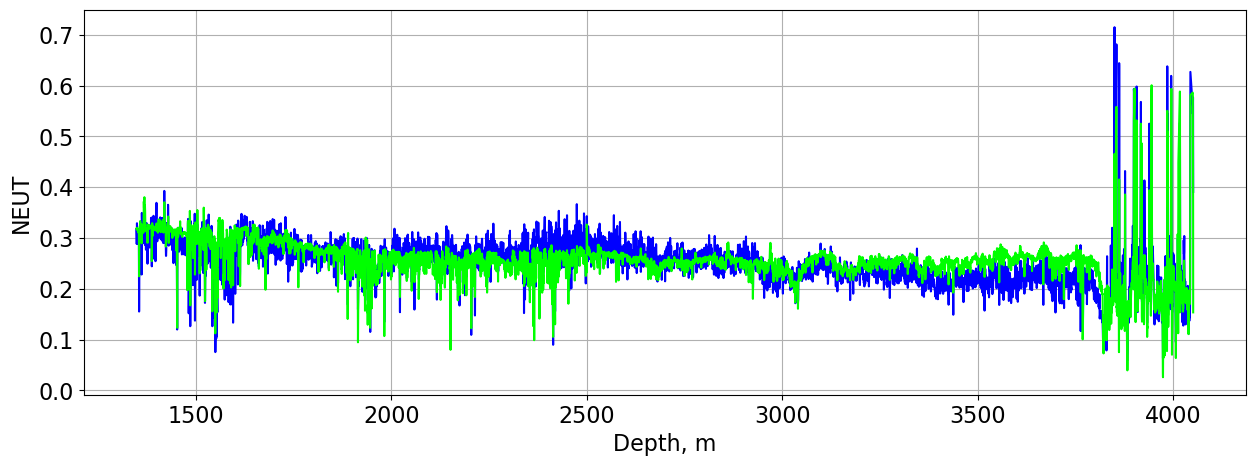

In [85]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color='blue')
plt.plot(test_well1['DEPT'], y_pred7_tw1.reshape(1,-1)[0], label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

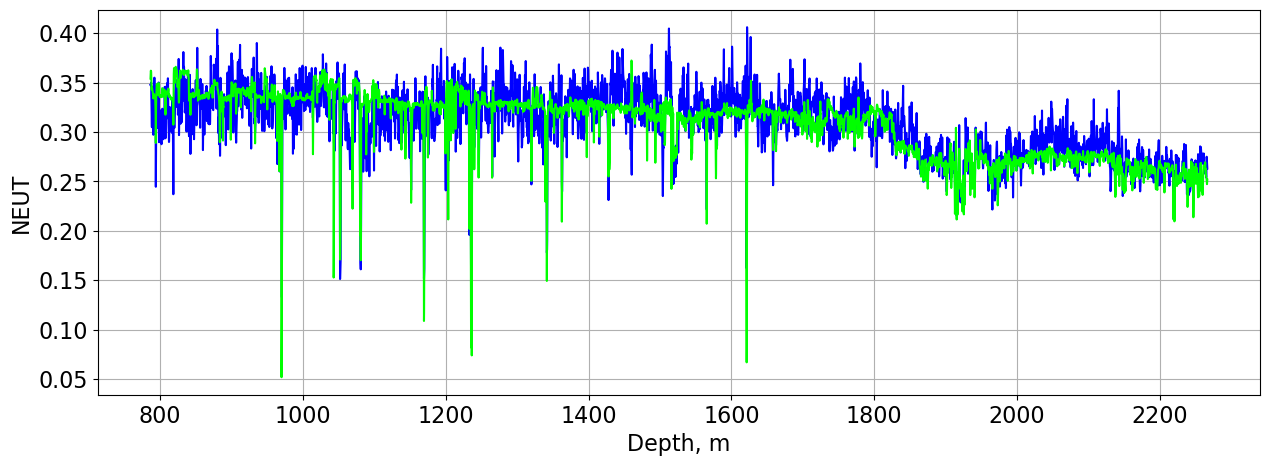

In [86]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color='blue')
plt.plot(test_well2['DEPT'], y_pred7_tw2.reshape(1,-1)[0], label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

# Model 8: Bagging Regressor

In [87]:
model8 = BaggingRegressor()
model8.fit(X_train, y_train)

BaggingRegressor()

In [88]:
y_pred8 = model8.predict(X_val)

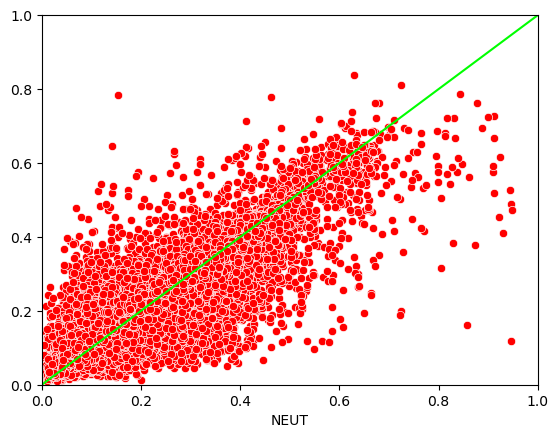

In [89]:
sns.scatterplot(x=y_val, y=y_pred8, color='red')
plt.xlim(0,1)
plt.ylim(0,1)
plt.plot((0, 1), (0, 1), color='lime')

In [90]:
y_pred8_tw1 = model8.predict(X_tw1_T)
y_pred8_tw2 = model8.predict(X_tw2_T)

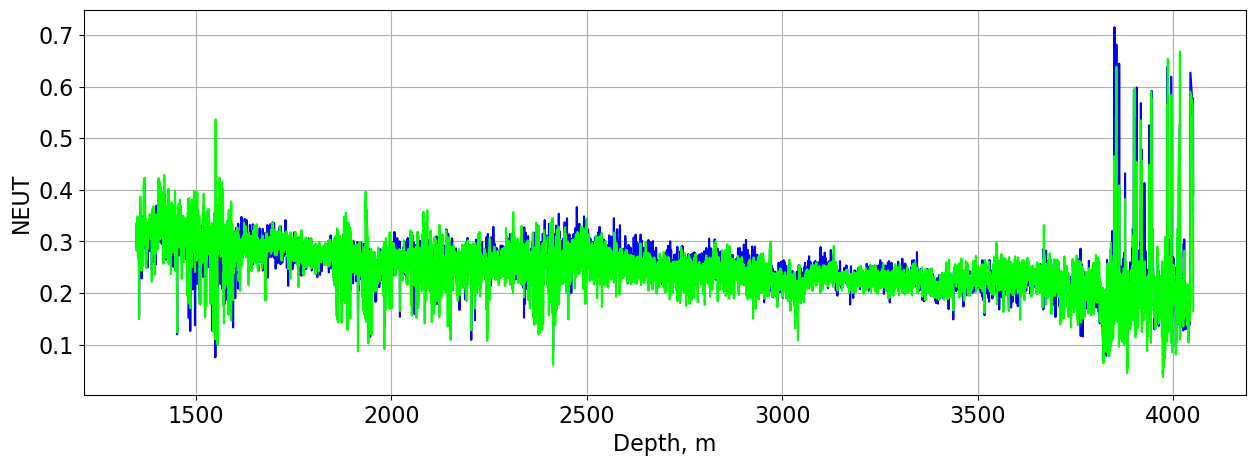

In [91]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color='blue')
plt.plot(test_well1['DEPT'], y_pred8_tw1, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

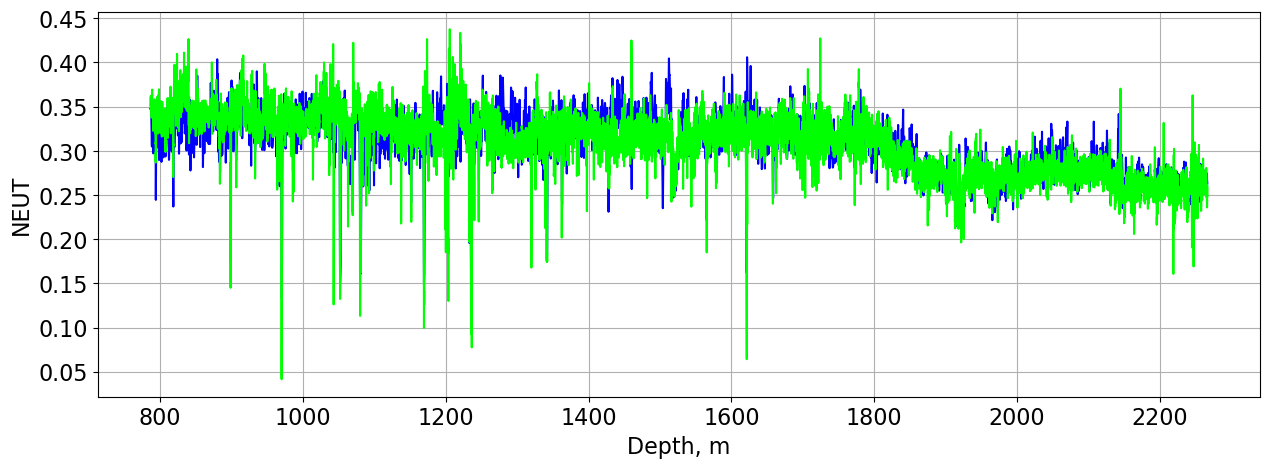

In [92]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color='blue')
plt.plot(test_well2['DEPT'], y_pred8_tw2, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

# Model 9: LGBMRegressor

In [93]:
from lightgbm import LGBMRegressor
model9 = LGBMRegressor()
model9.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006295 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 405395, number of used features: 3
[LightGBM] [Info] Start training from score 0.243190


LGBMRegressor()

In [94]:
y_pred9 = model9.predict(X_val)

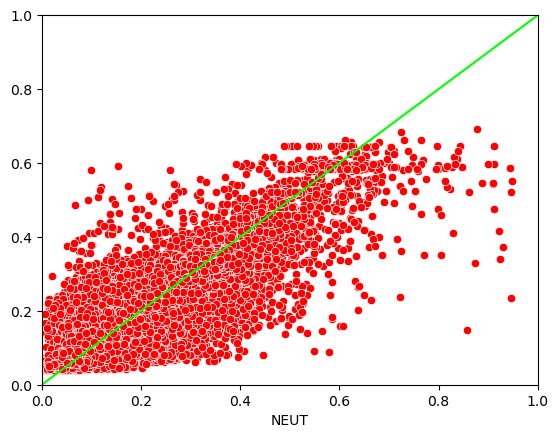

In [95]:
sns.scatterplot(x=y_val, y=y_pred9, color='red')
plt.xlim(0,1)
plt.ylim(0,1)
plt.plot((0, 1), (0, 1), color='lime')

In [96]:
y_pred9_tw1 = model9.predict(X_tw1_T)
y_pred9_tw2 = model9.predict(X_tw2_T)

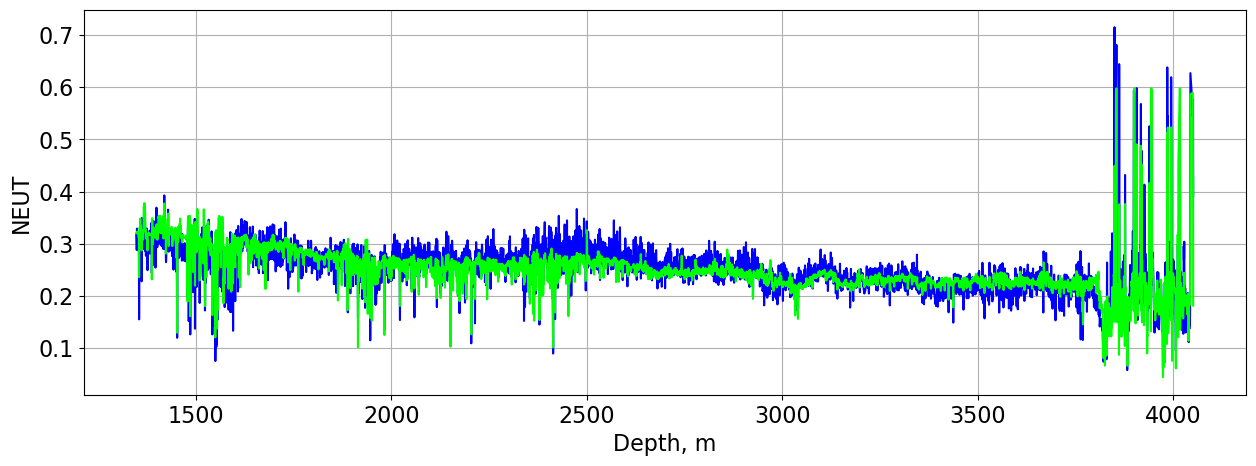

In [97]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color='blue')
plt.plot(test_well1['DEPT'], y_pred9_tw1, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

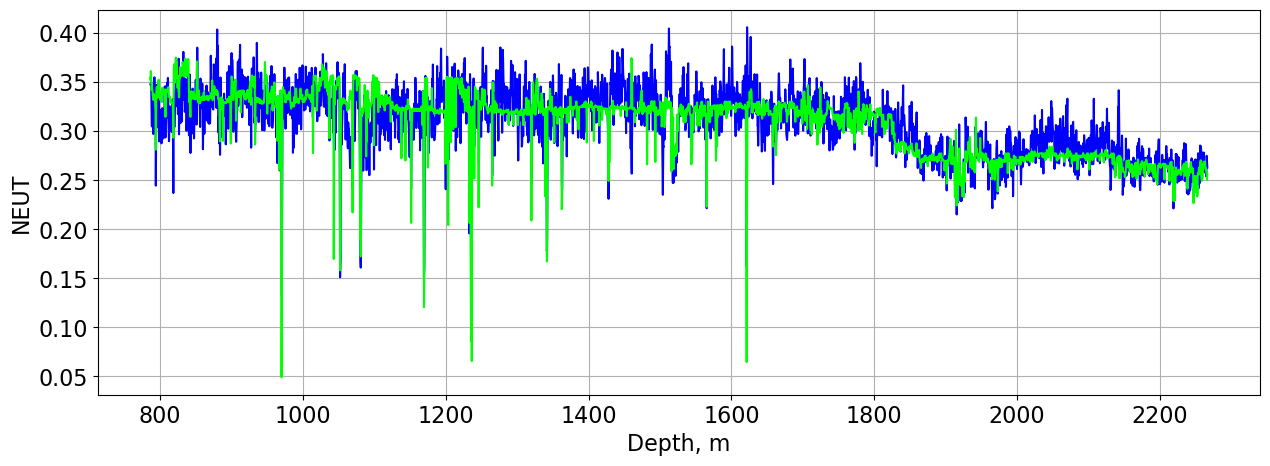

In [98]:
fontsize_ticks = 16
plt.figure(figsize = (15,5))
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color='blue')
plt.plot(test_well2['DEPT'], y_pred2_tw2, label='ŷ, Predicted NEUT', color='lime')
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.grid()

# Saving results

In [99]:
# Saving model results of 20% test data

model_val  = {'y_val':y_val, 'y_pred1': y_pred1, 'y_pred2': y_pred2, 'y_pred3': y_pred3, 
              'y_pred4': y_pred4, 'y_pred5': y_pred5, 'y_pred6': y_pred6,
              'y_pred7': y_pred7.reshape(1,-1)[0], 'y_pred8': y_pred8, 'y_pred9': y_pred9}
model_results_val = pd.DataFrame(data = model_val)
model_results_val.to_csv(#, index =False)
print(model_results_val)

          y_val   y_pred1   y_pred2   y_pred3  y_pred4   y_pred5   y_pred6  \
199100  0.31945  0.313534  0.320444  0.320411  0.29815  0.313044  0.322505   
382092  0.18461  0.169277  0.169797  0.154392  0.17384  0.166442  0.143664   
268449  0.30851  0.269413  0.292733  0.295958  0.27573  0.285628  0.293347   
416586  0.20455  0.160574  0.120894  0.154392  0.16811  0.135547  0.105632   
123845  0.23800  0.217544  0.214131  0.238217  0.21981  0.199905  0.211288   
...         ...       ...       ...       ...      ...       ...       ...   
156225  0.19432  0.190335  0.254905  0.238217  0.27732  0.307048  0.239125   
64724   0.34927  0.289633  0.312048  0.320411  0.34132  0.336902  0.308519   
16311   0.13058  0.172926  0.169510  0.187670  0.16678  0.166906  0.191122   
152065  0.19448  0.202479  0.224263  0.238217  0.25298  0.230472  0.232505   
336400  0.04287  0.142643  0.084178  0.154392  0.06958  0.087107  0.087516   

         y_pred7   y_pred8   y_pred9  
199100  0.320348  0.3108

In [100]:
X_tw1

,DENS,DTC,RESM
0,2.3449,101.9751,13.5747
1,2.3467,101.9682,13.8799
2,2.3484,101.9612,14.1851
3,2.3502,101.9543,14.4904
4,2.3500,101.9740,14.3954
...,...,...,...
17657,1.5591,112.5611,13.2266
17658,1.6938,100.8119,10.3549
17659,1.8634,91.5144,8.2962
17660,2.0968,86.6845,7.7187


In [101]:
# Saving model results of test well1

model_tw1  = {'test_well1 DEPT':test_well1['DEPT'],"y_tw1":y_tw1,
              'y_pred1_tw1': y_pred1_tw1, 'y_pred2_tw1': y_pred2_tw1, 'y_pred3_tw1': y_pred3_tw1, 
              'y_pred4_tw1': y_pred4_tw1, 'y_pred5_tw1': y_pred5_tw1, 'y_pred6_tw1': y_pred6_tw1,
              'y_pred7_tw1': y_pred7_tw1.reshape(1,-1)[0], 'y_pred8_tw1': y_pred8_tw1, 'y_pred9_tw1': y_pred9_tw1}
model_results_tw1 = pd.DataFrame(data = model_tw1)
model_results_tw1.to_csv(#, index =False)
print(model_results_tw1)

       test_well1 DEPT    y_tw1  y_pred1_tw1  y_pred2_tw1  y_pred3_tw1  \
0            1347.5208  0.31750     0.308161     0.321072     0.318045   
1            1347.6732  0.31446     0.308055     0.321072     0.318045   
2            1347.8256  0.31144     0.307953     0.321072     0.318045   
3            1347.9780  0.30841     0.307848     0.321072     0.318045   
4            1348.1304  0.30205     0.307931     0.321072     0.318045   
...                ...      ...          ...          ...          ...   
17657        4051.2492  0.56273     0.382797     0.466085     0.396127   
17658        4051.4016  0.57694     0.332636     0.415517     0.374518   
17659        4051.5540  0.55670     0.290151     0.413242     0.374518   
17660        4051.7064  0.47368     0.261642     0.372179     0.360793   
17661        4051.8588  0.39066     0.233134     0.187633     0.238217   

       y_pred4_tw1  y_pred5_tw1  y_pred6_tw1  y_pred7_tw1  y_pred8_tw1  \
0          0.34743     0.330710     0

In [102]:
# Saving model results of test well2
model_tw2 = {'test_well2 DEPT':test_well2['DEPT'],"y_tw2":y_tw2,
              'y_pred1_tw2': y_pred1_tw2, 'y_pred2_tw2': y_pred2_tw2, 'y_pred3_tw2': y_pred3_tw2, 
              'y_pred4_tw2': y_pred4_tw2, 'y_pred5_tw2': y_pred5_tw2, 'y_pred6_tw2': y_pred6_tw2,
              'y_pred7_tw2': y_pred7_tw2.reshape(1,-1)[0], 'y_pred8_tw2': y_pred8_tw2, 'y_pred9_tw2': y_pred9_tw2}
model_results_tw2 = pd.DataFrame(data=model_tw2)
model_results_tw2.to_csv(#, index=False)
print(model_results_tw2)


      test_well2 DEPT    y_tw2  y_pred1_tw2  y_pred2_tw2  y_pred3_tw2  \
0            786.5364  0.34774     0.368785     0.354350     0.346288   
1            786.6888  0.34742     0.372977     0.351836     0.355404   
2            786.8412  0.34709     0.377173     0.354192     0.355404   
3            786.9936  0.34677     0.381370     0.361280     0.355404   
4            787.1460  0.34777     0.380841     0.354192     0.355404   
...               ...      ...          ...          ...          ...   
9701        2265.8832  0.27157     0.226044     0.253080     0.238217   
9702        2266.0356  0.26976     0.225187     0.250524     0.238217   
9703        2266.1880  0.26751     0.226128     0.253752     0.238217   
9704        2266.3404  0.26526     0.227065     0.253874     0.238217   
9705        2266.4928  0.26301     0.228006     0.256005     0.238217   

      y_pred4_tw2  y_pred5_tw2  y_pred6_tw2  y_pred7_tw2  y_pred8_tw2  \
0         0.33032     0.344311     0.354289     0.

# Model Evaluation

In [103]:
mae_list = []
mse_list = []
rmse_list = []
maxerr_list = []
mape_list = []
r2_list = []
adj_r2_list = []

# evaluation on the 20% data split
model_list = ['Multi-LinearRegression','HistGradientBoosting','AdaBoost', 'DecisionTree', 'RandomForest', 
              'GradientBoosting', 'ANN', 'BaggingRegressor', 'LightGBM']
for i in [y_pred1,y_pred2,y_pred3,y_pred4,y_pred5, y_pred6,y_pred7,y_pred8, y_pred9]:
    mae = metrics.mean_absolute_error(y_val, i)
    mse = metrics.mean_squared_error(y_val, i)
    rmse = mse**0.5
    maxerr = metrics.max_error(y_val,i)
    mape = metrics.mean_absolute_percentage_error(y_val,i)
    r2 = metrics.r2_score(y_val,i)
    adj_r2 = 1 - ((1 - r2) * ((X.shape[0] - 1) / (X.shape[0] - X.shape[1] - 1)))
    mae_list.append(mae)
    mse_list.append(mse)
    rmse_list.append(rmse)
    maxerr_list.append(maxerr)
    mape_list.append(mape)
    r2_list.append(r2)
    adj_r2_list.append(adj_r2)
    

model_eval = {'Algorithm': model_list, 'MAE': mae_list, 'MSE': mse_list, 
              'RMSE': rmse_list, 'Max Error': maxerr_list, 'MAPE': mape_list, 'R2 score': r2_list, 'Adjusted R2': adj_r2_list}


model_eval_results = pd.DataFrame(data=model_eval)
model_eval_results.to_csv(#, index=False)
print(model_eval_results)


                Algorithm       MAE       MSE      RMSE  Max Error      MAPE  \
0  Multi-LinearRegression  0.043761  0.003632  0.060263   0.763804  0.347157   
1    HistGradientBoosting  0.028468  0.001780  0.042191   0.705867  0.180014   
2                AdaBoost  0.042305  0.003535  0.059453   0.672662  0.382218   
3            DecisionTree  0.035549  0.003153  0.056152   0.896720  0.212358   
4            RandomForest  0.026717  0.001705  0.041292   0.781954  0.166919   
5        GradientBoosting  0.031388  0.002042  0.045188   0.735081  0.203324   
6                     ANN  0.030616  0.002006  0.044793   0.749942  0.188402   
7        BaggingRegressor  0.027871  0.001838  0.042870   0.826235  0.172989   
8                LightGBM  0.028410  0.001774  0.042123   0.709572  0.179877   

   R2 score  Adjusted R2  
0  0.615249     0.615247  
1  0.811403     0.811402  
2  0.625517     0.625514  
3  0.665948     0.665946  
4  0.819359     0.819358  
5  0.783660     0.783659  
6  0.78743

In [106]:
model_eval_results

,Algorithm,MAE,MSE,RMSE,Max Error,MAPE,R2 score,Adjusted R2
0,Multi-LinearRegression,0.043761,0.003632,0.060263,0.763804,0.347157,0.615249,0.615247
1,HistGradientBoosting,0.028468,0.001780,0.042191,0.705867,0.180014,0.811403,0.811402
2,AdaBoost,0.042305,0.003535,0.059453,0.672662,0.382218,0.625517,0.625514
3,DecisionTree,0.035549,0.003153,0.056152,0.896720,0.212358,0.665948,0.665946
4,RandomForest,0.026717,0.001705,0.041292,0.781954,0.166919,0.819359,0.819358
5,GradientBoosting,0.031388,0.002042,0.045188,0.735081,0.203324,0.783660,0.783659
6,ANN,0.030616,0.002006,0.044793,0.749942,0.188402,0.787431,0.787429
7,BaggingRegressor,0.027871,0.001838,0.042870,0.826235,0.172989,0.805289,0.805288
8,LightGBM,0.028410,0.001774,0.042123,0.709572,0.179877,0.812018,0.812017


In [107]:
mae_list_tw1 = []
mse_list_tw1 = []
rmse_list_tw1 = []
maxerr_list_tw1 = []
mape_list_tw1 = []
r2_list_tw1 = []
adj_r2_list_tw1 = []

for i in [y_pred1_tw1, y_pred2_tw1, y_pred3_tw1, y_pred4_tw1, y_pred5_tw1, y_pred6_tw1, y_pred7_tw1, y_pred8_tw1, y_pred9_tw1]:
    mae_tw1 = metrics.mean_absolute_error(y_tw1, i)
    mse_tw1 = metrics.mean_squared_error(y_tw1, i)
    rmse_tw1 = mse_tw1 ** 0.5
    maxerr_tw1 = metrics.max_error(y_tw1, i)
    mape_tw1 = metrics.mean_absolute_percentage_error(y_tw1, i)
    r2_tw1 = metrics.r2_score(y_tw1, i)
    adj_r2_tw1 = 1 - ((1 - r2_tw1) * ((X.shape[0] - 1) / (X.shape[0] - X.shape[1] - 1)))

    mae_list_tw1.append(mae_tw1)
    mse_list_tw1.append(mse_tw1)
    rmse_list_tw1.append(rmse_tw1)
    maxerr_list_tw1.append(maxerr_tw1)
    mape_list_tw1.append(mape_tw1)
    r2_list_tw1.append(r2_tw1)
    adj_r2_list_tw1.append(adj_r2_tw1)

model_list_tw1 = model_list

model_eval_tw1 = {'Algorithm': model_list_tw1, 'MAE': mae_list_tw1, 'MSE': mse_list_tw1, 
                  'RMSE': rmse_list_tw1, 'Max Error': maxerr_list_tw1, 
                  'MAPE': mape_list_tw1, 'R2 score': r2_list_tw1, 'Adjusted R2': adj_r2_list_tw1}

model_eval_results_tw1 = pd.DataFrame(data=model_eval_tw1)
model_eval_results_tw1.to_csv(#, index=False)
print(model_eval_results_tw1)

                Algorithm       MAE       MSE      RMSE  Max Error      MAPE  \
0  Multi-LinearRegression  0.025749  0.001132  0.033643   0.353041  0.101918   
1    HistGradientBoosting  0.017396  0.000589  0.024267   0.284628  0.071533   
2                AdaBoost  0.025078  0.001050  0.032409   0.320911  0.108927   
3            DecisionTree  0.033385  0.002352  0.048494   0.567410  0.137753   
4            RandomForest  0.022150  0.000922  0.030368   0.350708  0.090603   
5        GradientBoosting  0.022892  0.000810  0.028465   0.255430  0.095059   
6                     ANN  0.022983  0.000861  0.029346   0.249194  0.097074   
7        BaggingRegressor  0.023417  0.001036  0.032193   0.394546  0.095969   
8                LightGBM  0.017489  0.000589  0.024263   0.269532  0.071890   

   R2 score  Adjusted R2  
0  0.423563     0.423560  
1  0.700074     0.700072  
2  0.465074     0.465071  
3 -0.197725    -0.197733  
4  0.530324     0.530322  
5  0.587336     0.587334  
6  0.56140

In [108]:
model_results_tw1

,test_well1 DEPT,y_tw1,y_pred1_tw1,y_pred2_tw1,y_pred3_tw1,y_pred4_tw1,y_pred5_tw1,y_pred6_tw1,y_pred7_tw1,y_pred8_tw1,y_pred9_tw1
0,1347.5208,0.31750,0.308161,0.321072,0.318045,0.34743,0.330710,0.320362,0.318738,0.327414,0.320383
1,1347.6732,0.31446,0.308055,0.321072,0.318045,0.33235,0.327312,0.320362,0.319004,0.323691,0.320383
2,1347.8256,0.31144,0.307953,0.321072,0.318045,0.33235,0.333369,0.320362,0.319255,0.335629,0.320383
3,1347.9780,0.30841,0.307848,0.321072,0.318045,0.33235,0.328096,0.320362,0.319522,0.332702,0.320383
4,1348.1304,0.30205,0.307931,0.321072,0.318045,0.33235,0.317794,0.320362,0.319535,0.281632,0.320383
...,...,...,...,...,...,...,...,...,...,...,...
17657,4051.2492,0.56273,0.382797,0.466085,0.396127,0.47405,0.409423,0.489980,0.509323,0.444970,0.423995
17658,4051.4016,0.57694,0.332636,0.415517,0.374518,0.54232,0.284556,0.454678,0.454808,0.355272,0.391623
17659,4051.5540,0.55670,0.290151,0.413242,0.374518,0.48365,0.465433,0.408849,0.426586,0.421182,0.429406
17660,4051.7064,0.47368,0.261642,0.372179,0.360793,0.36432,0.363890,0.363944,0.363579,0.355700,0.371998


In [109]:
mae_list_tw2 = []
mse_list_tw2 = []
rmse_list_tw2 = []
maxerr_list_tw2 = []
mape_list_tw2 = []
r2_list_tw2 = []
adj_r2_list_tw2 = []


for i in [y_pred1_tw2, y_pred2_tw2, y_pred3_tw2, y_pred4_tw2, y_pred5_tw2, y_pred6_tw2, y_pred7_tw2, y_pred8_tw2, y_pred9_tw2]:
    mae_tw2 = metrics.mean_absolute_error(y_tw2, i)
    mse_tw2 = metrics.mean_squared_error(y_tw2, i)
    rmse_tw2 = mse_tw2 ** 0.5
    maxerr_tw2 = metrics.max_error(y_tw2, i)
    mape_tw2 = metrics.mean_absolute_percentage_error(y_tw2, i)
    r2_tw2 = metrics.r2_score(y_tw2, i)
    adj_r2_tw2 = 1 - ((1 - r2_tw2) * ((X.shape[0] - 1) / (X.shape[0] - X.shape[1] - 1)))

    mae_list_tw2.append(mae_tw2)
    mse_list_tw2.append(mse_tw2)
    rmse_list_tw2.append(rmse_tw2)
    maxerr_list_tw2.append(maxerr_tw2)
    mape_list_tw2.append(mape_tw2)
    r2_list_tw2.append(r2_tw2)
    adj_r2_list_tw2.append(adj_r2_tw2)


model_list_tw2 = model_list

model_eval_tw2 = {'Algorithm': model_list_tw2, 'MAE': mae_list_tw2, 'MSE': mse_list_tw2, 
                  'RMSE': rmse_list_tw2, 'Max Error': maxerr_list_tw2, 
                  'MAPE': mape_list_tw2, 'R2 score': r2_list_tw2, 'Adjusted R2': adj_r2_list_tw2}

model_eval_results_tw2 = pd.DataFrame(data=model_eval_tw2)
model_eval_results_tw2.to_csv(#, index=False)
# Print the results
print(model_eval_results_tw2)


                Algorithm       MAE       MSE      RMSE  Max Error      MAPE  \
0  Multi-LinearRegression  0.027864  0.001070  0.032707   0.168915  0.091091   
1    HistGradientBoosting  0.015776  0.000428  0.020683   0.164233  0.051468   
2                AdaBoost  0.017032  0.000471  0.021709   0.167723  0.055064   
3            DecisionTree  0.027621  0.001427  0.037782   0.367340  0.090421   
4            RandomForest  0.018616  0.000593  0.024348   0.153719  0.060509   
5        GradientBoosting  0.017544  0.000494  0.022218   0.166859  0.057158   
6                     ANN  0.016520  0.000460  0.021448   0.165638  0.053924   
7        BaggingRegressor  0.019570  0.000660  0.025690   0.192117  0.063747   
8                LightGBM  0.015816  0.000428  0.020683   0.166078  0.051635   

   R2 score  Adjusted R2  
0 -0.038401    -0.038407  
1  0.584755     0.584753  
2  0.542514     0.542512  
3 -0.385662    -0.385670  
4  0.424534     0.424531  
5  0.520808     0.520805  
6  0.55346

In [110]:
model_results_tw2

,test_well2 DEPT,y_tw2,y_pred1_tw2,y_pred2_tw2,y_pred3_tw2,y_pred4_tw2,y_pred5_tw2,y_pred6_tw2,y_pred7_tw2,y_pred8_tw2,y_pred9_tw2
0,786.5364,0.34774,0.368785,0.354350,0.346288,0.33032,0.344311,0.354289,0.353948,0.351433,0.354338
1,786.6888,0.34742,0.372977,0.351836,0.355404,0.36835,0.355274,0.353769,0.357014,0.353630,0.353414
2,786.8412,0.34709,0.377173,0.354192,0.355404,0.35061,0.361684,0.356265,0.359643,0.361298,0.354320
3,786.9936,0.34677,0.381370,0.361280,0.355404,0.34670,0.346350,0.358122,0.361986,0.353322,0.360946
4,787.1460,0.34777,0.380841,0.354192,0.355404,0.36503,0.349925,0.358122,0.361712,0.344539,0.354795
...,...,...,...,...,...,...,...,...,...,...,...
9701,2265.8832,0.27157,0.226044,0.253080,0.238217,0.26218,0.241067,0.241883,0.248094,0.241112,0.254015
9702,2266.0356,0.26976,0.225187,0.250524,0.238217,0.23386,0.237768,0.241893,0.247182,0.235956,0.254015
9703,2266.1880,0.26751,0.226128,0.253752,0.238217,0.24024,0.245835,0.241883,0.248717,0.236856,0.254015
9704,2266.3404,0.26526,0.227065,0.253874,0.238217,0.26371,0.249779,0.241883,0.250268,0.260802,0.255228


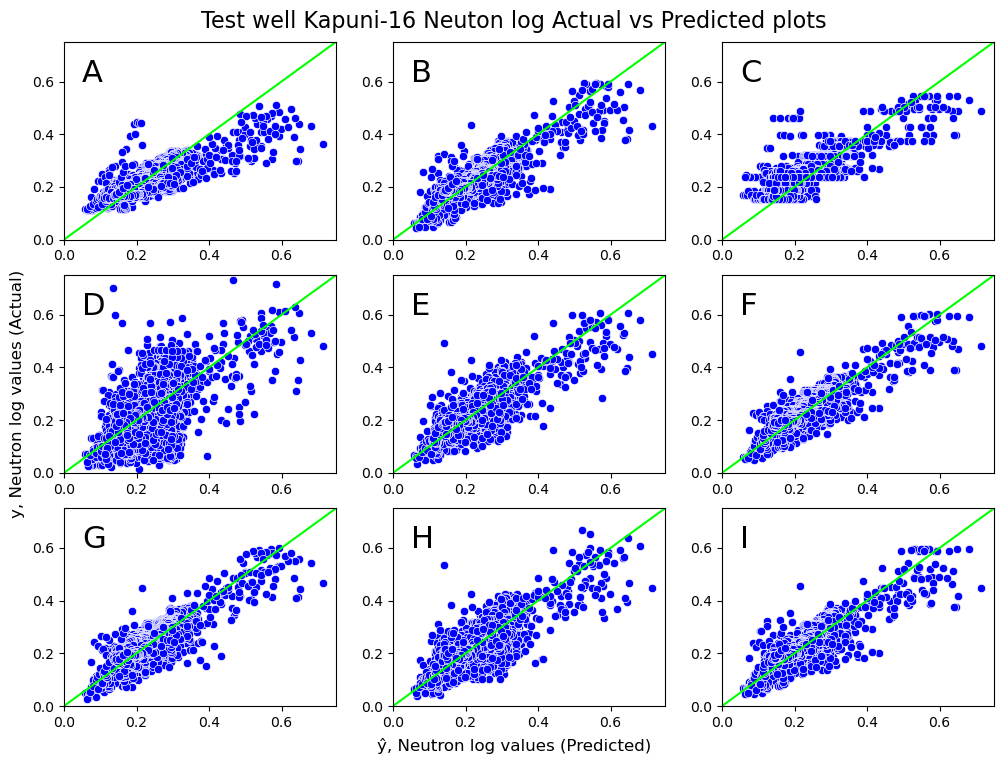

In [111]:
fig = plt.figure(figsize=(12, 8))

# Define colors and font size
scatter_color = 'blue'
line_color = 'lime'
font_size = 16

# Subplot 1
ax1 = fig.add_subplot(3, 3, 1)
sns.scatterplot(x=y_tw1, y=y_pred1_tw1, color=scatter_color)
plt.plot((0, 0.75), (0, 0.75), color=line_color)  # Adjusted line
plt.xlim(0, 0.75)
plt.ylim(0, 0.75)
plt.xlabel("")
plt.text(0.05, 0.60, "A", fontsize=22)

# Subplot 2
ax2 = fig.add_subplot(3, 3, 2)
sns.scatterplot(x=y_tw1, y=y_pred2_tw1, color=scatter_color)
plt.plot((0, 0.75), (0, 0.75), color=line_color)  # Adjusted line
plt.xlim(0, 0.75)
plt.ylim(0, 0.75)
plt.xlabel("")
plt.text(0.05, 0.60, "B", fontsize=22)

# Subplot 3
ax3 = fig.add_subplot(3, 3, 3)
sns.scatterplot(x=y_tw1, y=y_pred3_tw1, color=scatter_color)
plt.plot((0, 0.75), (0, 0.75), color=line_color)  # Adjusted line
plt.xlim(0, 0.75)
plt.ylim(0, 0.75)
plt.xlabel("")
plt.text(0.05, 0.60, "C", fontsize=22)

# Subplot 4
ax4 = fig.add_subplot(3, 3, 4)
sns.scatterplot(x=y_tw1, y=y_pred4_tw1, color=scatter_color)
plt.plot((0, 0.75), (0, 0.75), color=line_color)  # Adjusted line
plt.xlim(0, 0.75)
plt.ylim(0, 0.75)
plt.xlabel("")
plt.text(0.05, 0.60, "D", fontsize=22)

# Subplot 5
ax5 = fig.add_subplot(3, 3, 5)
sns.scatterplot(x=y_tw1, y=y_pred5_tw1, color=scatter_color)
plt.plot((0, 0.75), (0, 0.75), color=line_color)  # Adjusted line
plt.xlim(0, 0.75)
plt.ylim(0, 0.75)
plt.xlabel("")
plt.text(0.05, 0.60, "E", fontsize=22)

# Subplot 6
ax6 = fig.add_subplot(3, 3, 6)
sns.scatterplot(x=y_tw1, y=y_pred6_tw1, color=scatter_color)
plt.plot((0, 0.75), (0, 0.75), color=line_color)  # Adjusted line
plt.xlim(0, 0.75)
plt.ylim(0, 0.75)
plt.xlabel("")
plt.text(0.05, 0.60, "F", fontsize=22)

# Subplot 7
ax7 = fig.add_subplot(3, 3, 7)
sns.scatterplot(x=y_tw1, y=y_pred7_tw1.reshape(1, -1)[0], color=scatter_color)
plt.plot((0, 0.75), (0, 0.75), color=line_color)  # Adjusted line
plt.xlim(0, 0.75)
plt.ylim(0, 0.75)
plt.xlabel("")
plt.text(0.05, 0.60, "G", fontsize=22)

# Subplot 8
ax8 = fig.add_subplot(3, 3, 8)
sns.scatterplot(x=y_tw1, y=y_pred8_tw1, color=scatter_color)
plt.plot((0, 0.75), (0, 0.75), color=line_color)  # Adjusted line
plt.xlim(0, 0.75)
plt.ylim(0, 0.75)
plt.xlabel("")
plt.text(0.05, 0.60, "H", fontsize=22)

# Subplot 9
ax9 = fig.add_subplot(3, 3, 9)
sns.scatterplot(x=y_tw1, y=y_pred9_tw1, color=scatter_color)
plt.plot((0, 0.75), (0, 0.75), color=line_color)  # Adjusted line
plt.xlim(0, 0.75)
plt.ylim(0, 0.75)
plt.xlabel("")
plt.text(0.05, 0.60, "I", fontsize=22)

fig.suptitle('Test well Kapuni-16 Neuton log Actual vs Predicted plots', fontsize  = 16)
fig.supylabel('y, Neutron log values (Actual)',x = 0.08, y =0.5, fontsize = 12)
fig.supxlabel('ŷ, Neutron log values (Predicted)', x = 0.5,y = 0.05,fontsize = 12)

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.21, hspace=0.18)
fig.subplots_adjust(top=0.94)

# Adjust layout
# fig.tight_layout()

plt.savefig('well logs results test_well1.png', dpi = 1200,  bbox_inches='tight')
# plt.show()

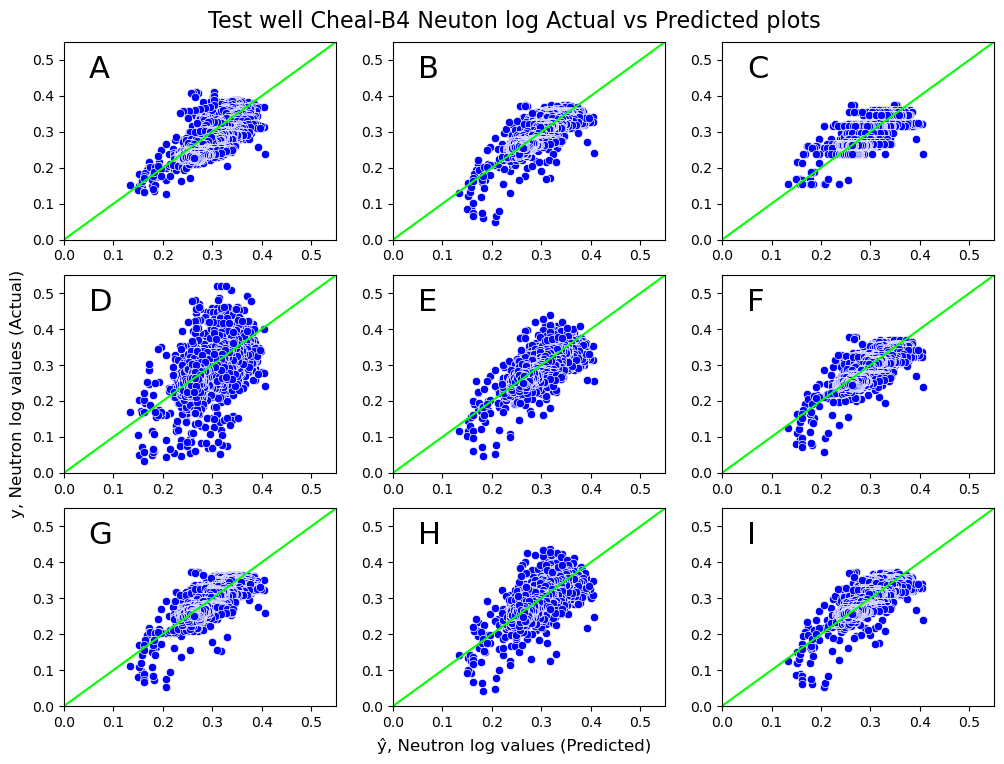

In [112]:
fig = plt.figure(figsize=(12, 8))

# Define colors and font size
scatter_color = 'blue'
line_color = 'lime'
font_size = 16

# Subplot 1
ax1 = fig.add_subplot(3, 3, 1)
sns.scatterplot(x=y_tw2, y=y_pred1_tw2, color=scatter_color)
plt.plot((0, 0.55), (0, 0.55), color=line_color)  # Adjusted line
plt.xlim(0, 0.55)
plt.ylim(0, 0.55)
plt.xlabel("")
plt.text(0.05, 0.45, "A", fontsize=22)

# Subplot 2
ax2 = fig.add_subplot(3, 3, 2)
sns.scatterplot(x=y_tw2, y=y_pred2_tw2, color=scatter_color)
plt.plot((0, 0.55), (0, 0.55), color=line_color)  # Adjusted line
plt.xlim(0, 0.55)
plt.ylim(0, 0.55)
plt.xlabel("")
plt.text(0.05, 0.45, "B", fontsize=22)

# Subplot 3
ax3 = fig.add_subplot(3, 3, 3)
sns.scatterplot(x=y_tw2, y=y_pred3_tw2, color=scatter_color)
plt.plot((0, 0.55), (0, 0.55), color=line_color)  # Adjusted line
plt.xlim(0, 0.55)
plt.ylim(0, 0.55)
plt.xlabel("")
plt.text(0.05, 0.45, "C", fontsize=22)

# Subplot 4
ax4 = fig.add_subplot(3, 3, 4)
sns.scatterplot(x=y_tw2, y=y_pred4_tw2, color=scatter_color)
plt.plot((0, 0.55), (0, 0.55), color=line_color)  # Adjusted line
plt.xlim(0, 0.55)
plt.ylim(0, 0.55)
plt.xlabel("")
plt.text(0.05, 0.45, "D", fontsize=22)

# Subplot 5
ax5 = fig.add_subplot(3, 3, 5)
sns.scatterplot(x=y_tw2, y=y_pred5_tw2, color=scatter_color)
plt.plot((0, 0.55), (0, 0.55), color=line_color)  # Adjusted line
plt.xlim(0, 0.55)
plt.ylim(0, 0.55)
plt.xlabel("")
plt.text(0.05, 0.45, "E", fontsize=22)

# Subplot 6
ax6 = fig.add_subplot(3, 3, 6)
sns.scatterplot(x=y_tw2, y=y_pred6_tw2, color=scatter_color)
plt.plot((0, 0.55), (0, 0.55), color=line_color)  # Adjusted line
plt.xlim(0, 0.55)
plt.ylim(0, 0.55)
plt.xlabel("")
plt.text(0.05, 0.45, "F", fontsize=22)

# Subplot 7
ax7 = fig.add_subplot(3, 3, 7)
sns.scatterplot(x=y_tw2, y=y_pred7_tw2.reshape(1, -1)[0], color=scatter_color)
plt.plot((0, 0.55), (0, 0.55), color=line_color)  # Adjusted line
plt.xlim(0, 0.55)
plt.ylim(0, 0.55)
plt.xlabel("")
plt.text(0.05, 0.45, "G", fontsize=22)

# Subplot 8
ax8 = fig.add_subplot(3, 3, 8)
sns.scatterplot(x=y_tw2, y=y_pred8_tw2, color=scatter_color)
plt.plot((0, 0.55), (0, 0.55), color=line_color)  # Adjusted line
plt.xlim(0, 0.55)
plt.ylim(0, 0.55)
plt.xlabel("")
plt.text(0.05, 0.45, "H", fontsize=22)

# Subplot 9
ax9 = fig.add_subplot(3, 3, 9)
sns.scatterplot(x=y_tw2, y=y_pred9_tw2, color=scatter_color)
plt.plot((0, 0.55), (0, 0.55), color=line_color)  # Adjusted line
plt.xlim(0, 0.55)
plt.ylim(0, 0.55)
plt.xlabel("")
plt.text(0.05, 0.45, "I", fontsize=22)

fig.suptitle('Test well Cheal-B4 Neuton log Actual vs Predicted plots', fontsize=16)
fig.supylabel('y, Neutron log values (Actual)', x=0.08, y=0.5, fontsize=12)
fig.supxlabel('ŷ, Neutron log values (Predicted)', x=0.5, y=0.05, fontsize=12)

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.21, hspace=0.18)
fig.subplots_adjust(top=0.94)

# Adjust layout
# fig.tight_layout()

plt.savefig('act vs pred test_well2.png', dpi = 1200,  bbox_inches='tight')
plt.show()


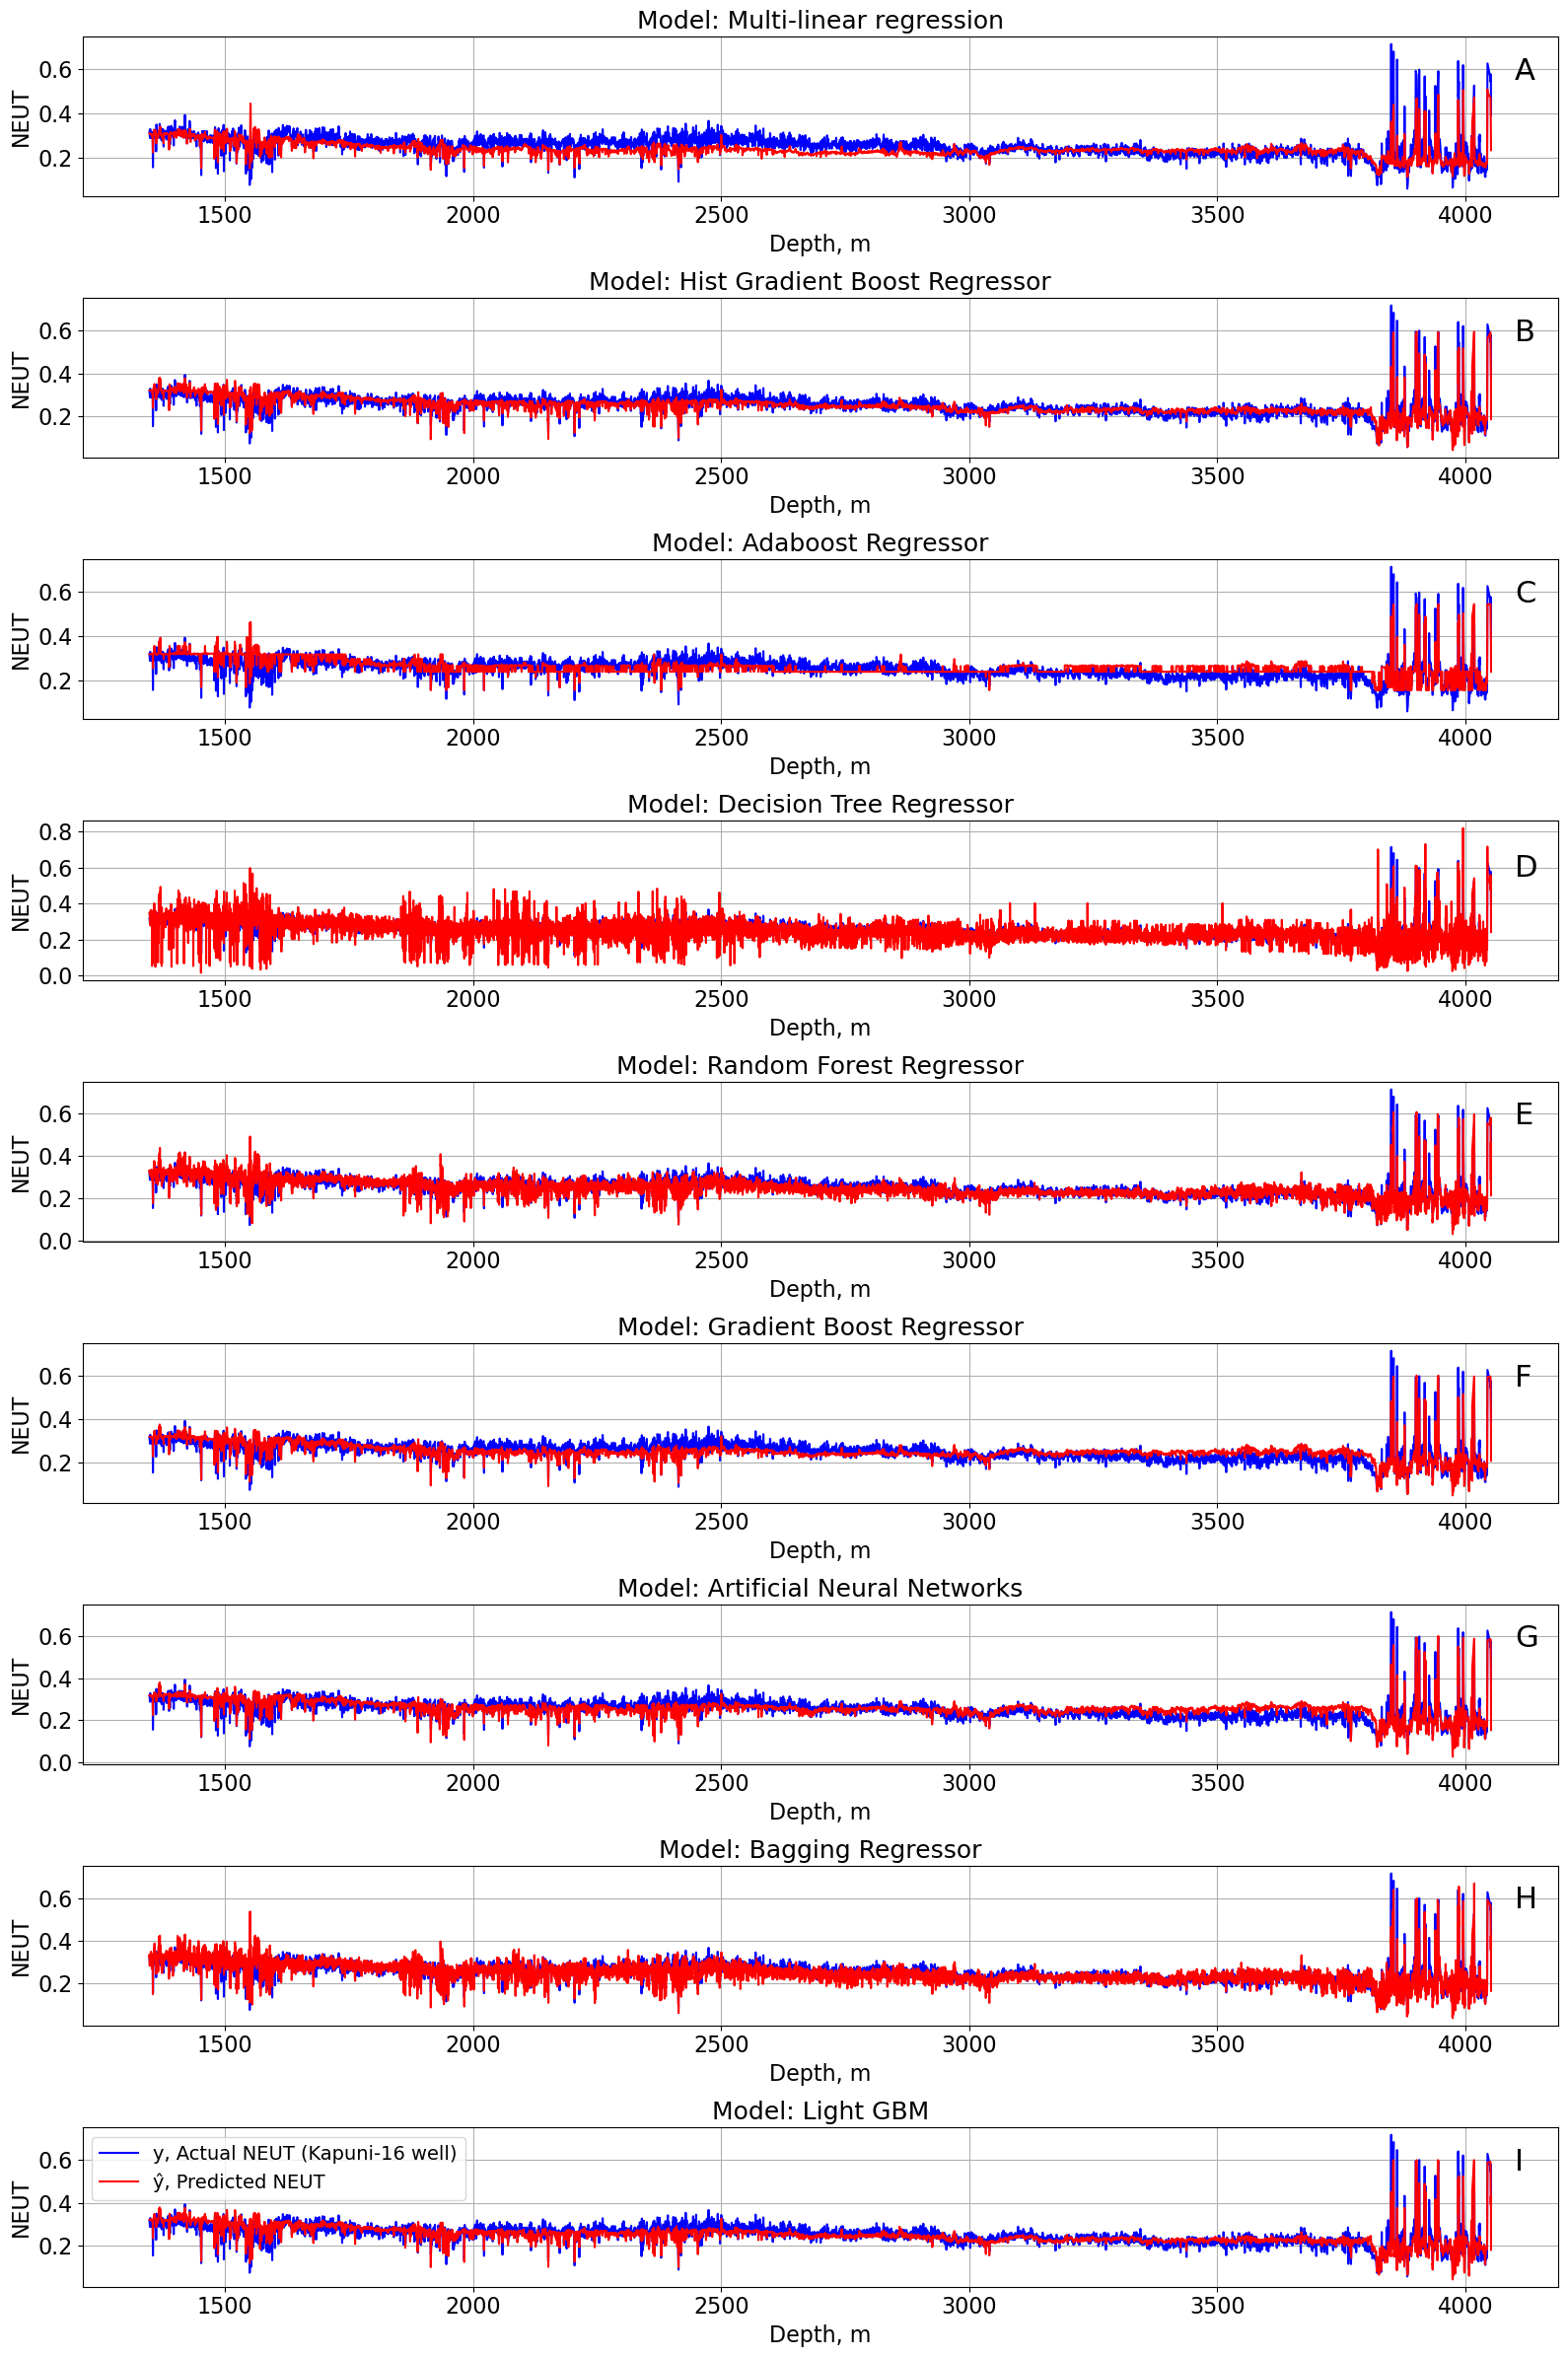

In [113]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16, 24))

# Define colors and font size
actual_color = 'blue'
predicted_color = 'red'
fontsize_title = 18
fontsize_ticks = 16
font_figmark = 22
legend_font = 14 

# Plot for Model 1: Multi-linear regression
plt.subplot(9, 1, 1)
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color=actual_color)
plt.plot(test_well1['DEPT'], y_pred1_tw1, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Multi-linear regression', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(4100, 0.55, 'A', fontsize=font_figmark)
plt.grid()

# Plot for Model 2: Hist Gradient Boost Regressor
plt.subplot(9, 1, 2)
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color=actual_color)
plt.plot(test_well1['DEPT'], y_pred2_tw1, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Hist Gradient Boost Regressor', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(4100, 0.55, 'B', fontsize=font_figmark)
plt.grid()

# Plot for Model 3: Adaboost Regressor
plt.subplot(9, 1, 3)
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color=actual_color)
plt.plot(test_well1['DEPT'], y_pred3_tw1, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Adaboost Regressor', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(4100, 0.55, 'C', fontsize=font_figmark)
plt.grid()

# Plot for Model 4: Decision Tree Regressor
plt.subplot(9, 1, 4)
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color=actual_color)
plt.plot(test_well1['DEPT'], y_pred4_tw1, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Decision Tree Regressor', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(4100, 0.55, 'D', fontsize=font_figmark)
plt.grid()

# Plot for Model 5: Random Forest Regressor
plt.subplot(9, 1, 5)
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color=actual_color)
plt.plot(test_well1['DEPT'], y_pred5_tw1, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Random Forest Regressor', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(4100, 0.55, 'E', fontsize=font_figmark)
plt.grid()

# Plot for Model 6: Gradient Boost Regressor
plt.subplot(9, 1, 6)
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color=actual_color)
plt.plot(test_well1['DEPT'], y_pred6_tw1, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Gradient Boost Regressor', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(4100, 0.55, 'F', fontsize=font_figmark)
plt.grid()

# Plot for Model 7: Artificial Neural Networks
plt.subplot(9, 1, 7)
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color=actual_color)
plt.plot(test_well1['DEPT'], y_pred7_tw1, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Artificial Neural Networks', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(4100, 0.55, 'G', fontsize=font_figmark)
plt.grid()

# Plot for Model 8: Bagging Regressor
plt.subplot(9, 1, 8)
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color=actual_color)
plt.plot(test_well1['DEPT'], y_pred8_tw1, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Bagging Regressor', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(4100, 0.55, 'H', fontsize=font_figmark)
plt.grid()

# Plot for Model 9: Light GBM
plt.subplot(9, 1, 9)
plt.plot(test_well1['DEPT'], y_tw1, label='y, Actual NEUT (Kapuni-16 well)', color=actual_color)
plt.plot(test_well1['DEPT'], y_pred9_tw1, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Light GBM', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(4100, 0.55, 'I', fontsize=font_figmark)
plt.legend(fontsize = legend_font,loc= 'upper left')
plt.grid()

plt.tight_layout()

plt.savefig('well logs results test_well1.png', dpi = 1200,  bbox_inches='tight')
plt.show()


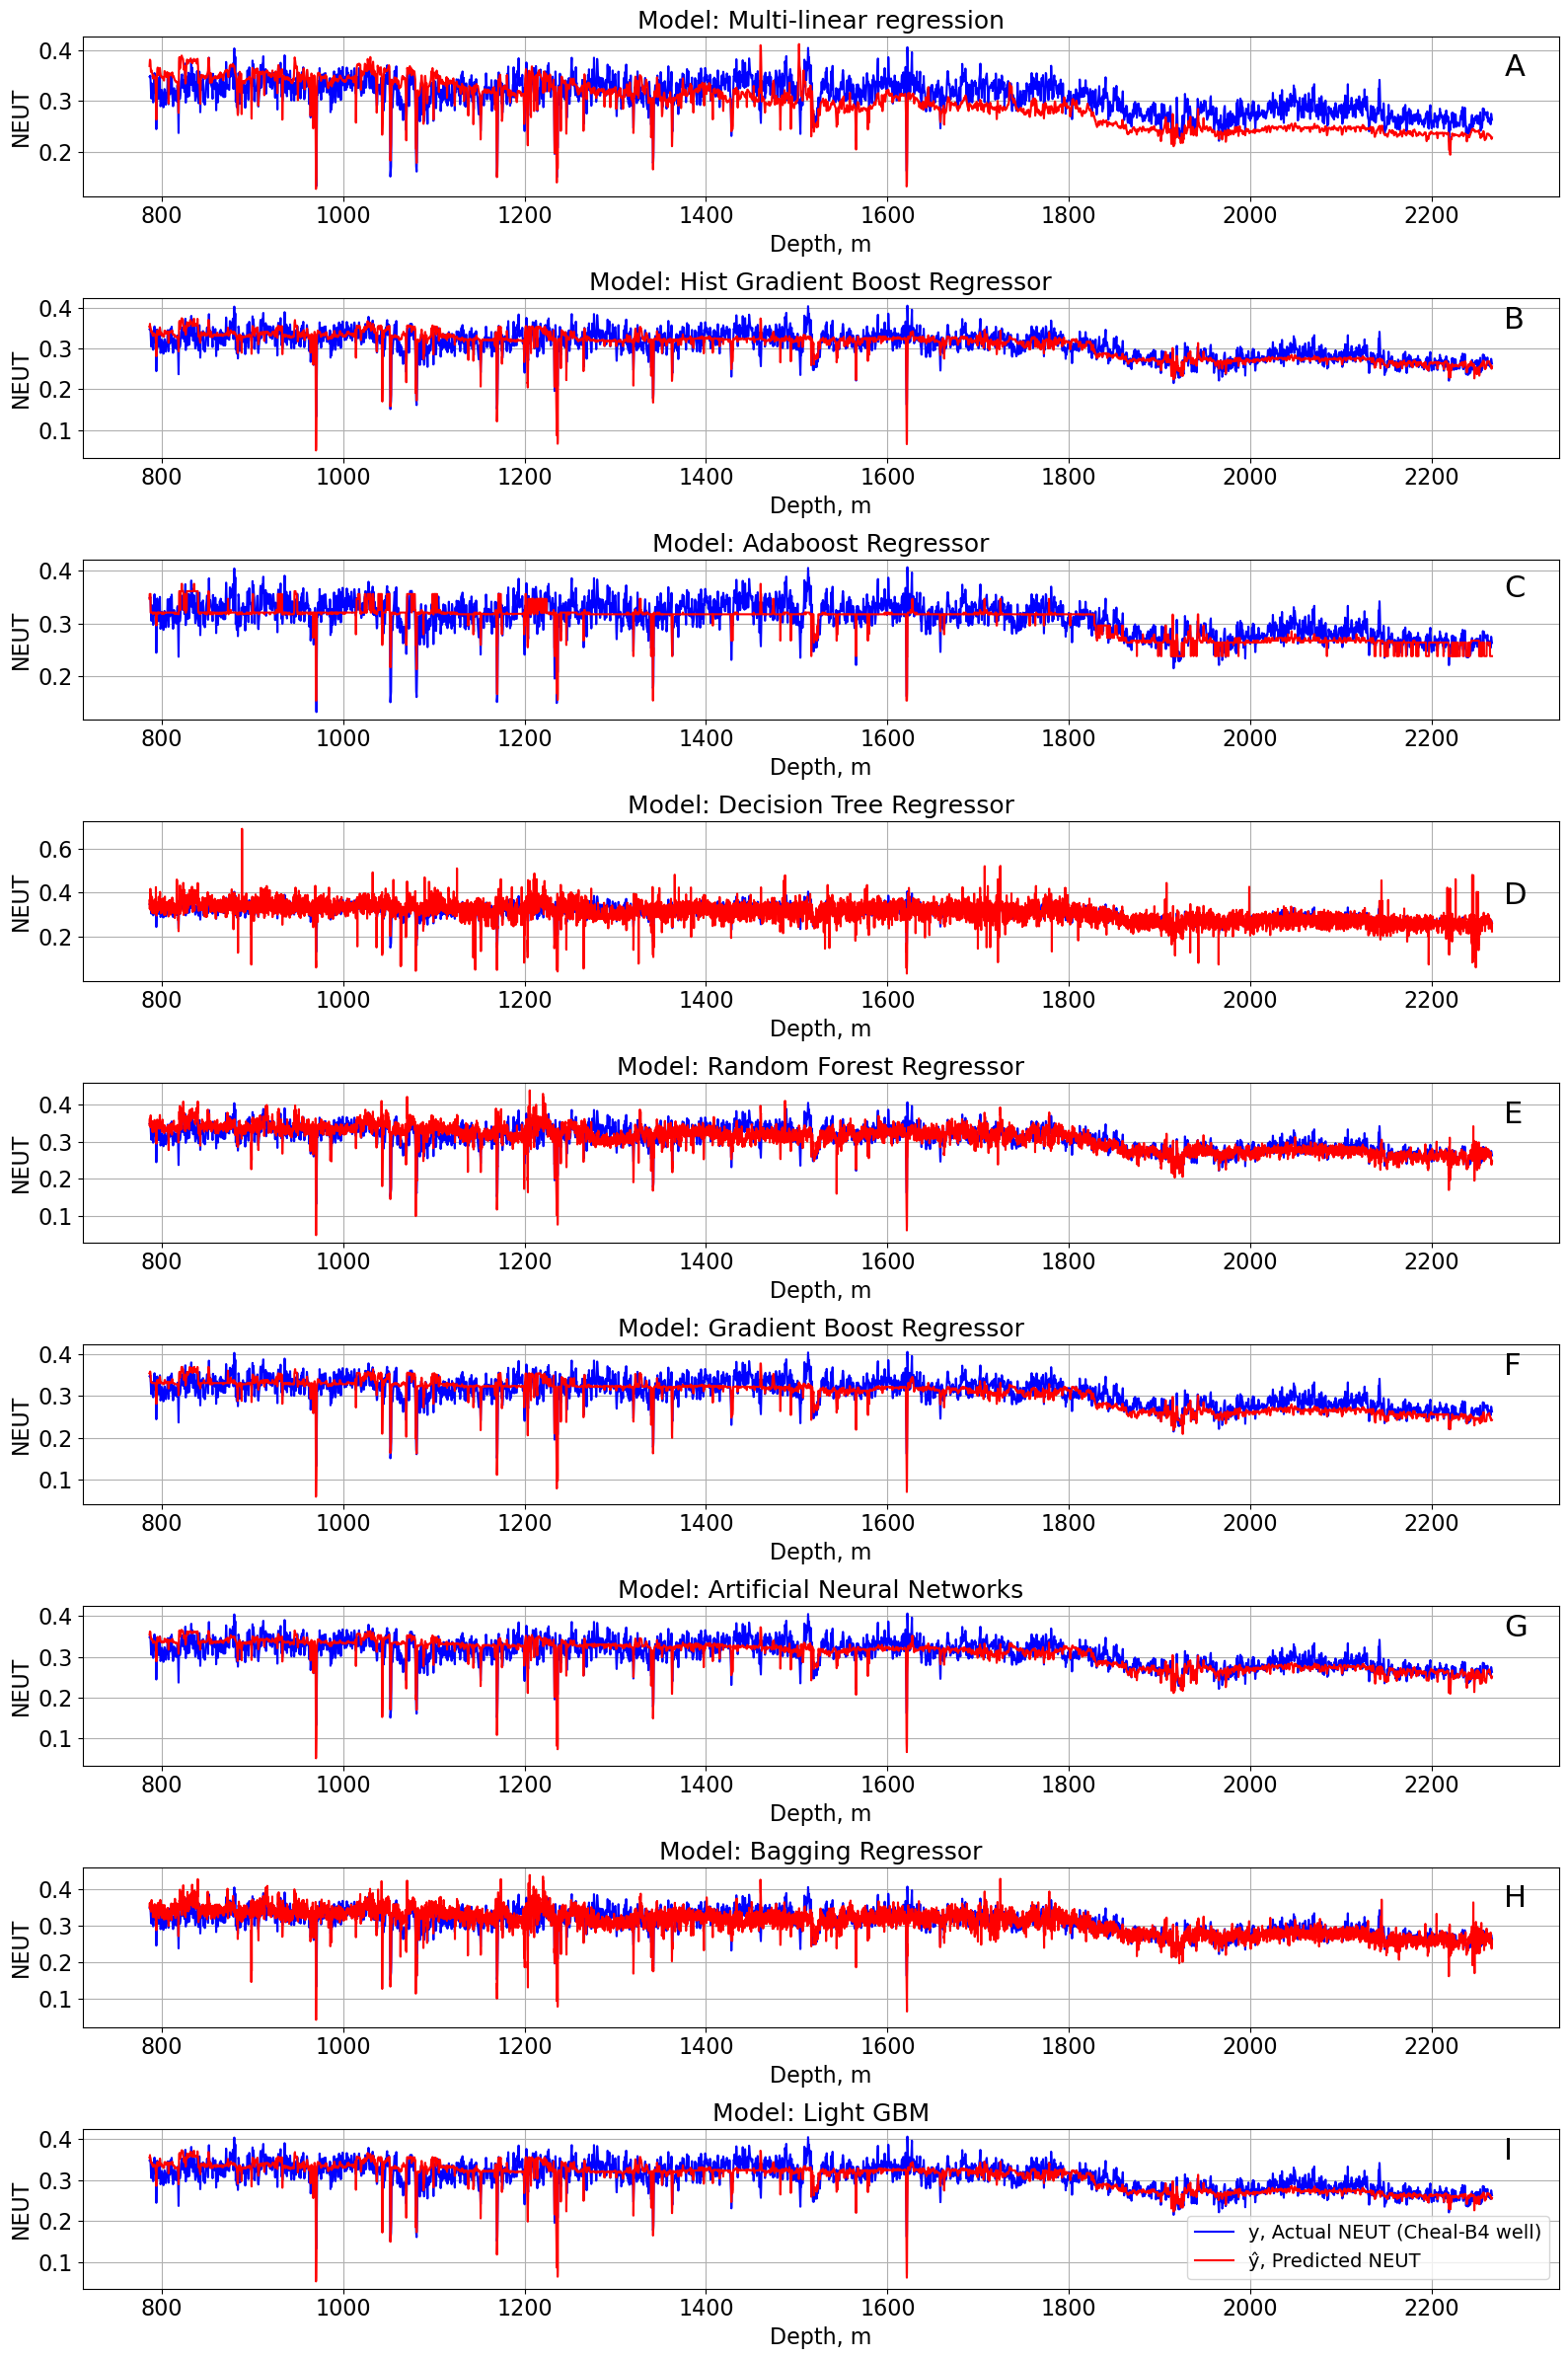

In [114]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16, 24))

# Define colors and font size
actual_color = 'blue'
predicted_color = 'red'
fontsize_title = 18
fontsize_ticks = 16
legend_font = 14
font_figmark = 22

# Plot for Model 1: Multi-linear regression
plt.subplot(9, 1, 1)
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color=actual_color)
plt.plot(test_well2['DEPT'], y_pred1_tw2, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Multi-linear regression', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(2280, 0.35, 'A', fontsize=font_figmark)
plt.grid()

# Plot for Model 2: Hist Gradient Boost Regressor
plt.subplot(9, 1, 2)
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color=actual_color)
plt.plot(test_well2['DEPT'], y_pred2_tw2, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Hist Gradient Boost Regressor', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(2280, 0.35, 'B', fontsize=font_figmark)
plt.grid()

# Plot for Model 3: Adaboost Regressor
plt.subplot(9, 1, 3)
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color=actual_color)
plt.plot(test_well2['DEPT'], y_pred3_tw2, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Adaboost Regressor', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(2280, 0.35, 'C', fontsize=font_figmark)
plt.grid()

# Plot for Model 4: Decision Tree Regressor
plt.subplot(9, 1, 4)
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color=actual_color)
plt.plot(test_well2['DEPT'], y_pred4_tw2, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Decision Tree Regressor', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(2280, 0.35, 'D', fontsize=font_figmark)
plt.grid()

# Plot for Model 5: Random Forest Regressor
plt.subplot(9, 1, 5)
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color=actual_color)
plt.plot(test_well2['DEPT'], y_pred5_tw2, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Random Forest Regressor', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(2280, 0.35, 'E', fontsize=font_figmark)
plt.grid()

# Plot for Model 6: Gradient Boost Regressor
plt.subplot(9, 1, 6)
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color=actual_color)
plt.plot(test_well2['DEPT'], y_pred6_tw2, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Gradient Boost Regressor', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(2280, 0.35, 'F', fontsize=font_figmark)
plt.grid()

# Plot for Model 7: Artificial Neural Networks
plt.subplot(9, 1, 7)
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color=actual_color)
plt.plot(test_well2['DEPT'], y_pred7_tw2, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Artificial Neural Networks', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(2280, 0.35, 'G', fontsize=font_figmark)
plt.grid()

# Plot for Model 8: Bagging Regressor
plt.subplot(9, 1, 8)
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color=actual_color)
plt.plot(test_well2['DEPT'], y_pred8_tw2, label='ŷ, Predicted NEUT', color=predicted_color)
plt.title('Model: Bagging Regressor', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(2280, 0.35, 'H', fontsize=font_figmark)
plt.grid()

# Plot for Model 9: Light GBM
plt.subplot(9, 1, 9)
plt.plot(test_well2['DEPT'], y_tw2, label='y, Actual NEUT (Cheal-B4 well)', color=actual_color)
plt.plot(test_well2['DEPT'], y_pred9_tw2, label='ŷ, Predicted NEUT', color=predicted_color)

plt.title('Model: Light GBM', fontsize=fontsize_title)
plt.xlabel('Depth, m', fontsize=fontsize_ticks)
plt.ylabel('NEUT', fontsize=fontsize_ticks)  # Changed label to NEUT
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.text(2280, 0.35, 'I', fontsize=font_figmark)
plt.grid()
plt.legend(fontsize = legend_font)

plt.tight_layout()

plt.savefig('well logs results test_well2.png', dpi = 1200,  bbox_inches='tight')
plt.show()
